In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import glob
import pandas as pd
import datetime
import numpy as np
import polars as pl
from pathlib import Path
from datetime import timedelta
import datetime
import missingno as msno


# DATA2
주제 2. 구독서비스 프로덕트 데이터 분석

| #  | 컬럼명              | 컬럼 설명                                                     | 컬럼 타입  | 비고                                                                                                                                   |
|:--:|:-------------------|:-------------------------------------------------------------|:---------|:---------------------------------------------------------------------------------------------------------------------------------------|
| 1  | **city**           | 접속 위치                                                    | Object   | 국내 기준 “시” 단위로 제공하나, 서울의 경우 “구”가 특정되는 경우는 “구” 단위로 표기                                                |
| 2  | **client_event_time** | 타임스탬프 (UTC+0 기준)                                   | Object   | -                                                                                                                                     |
| 3  | **country**        | 접속 국가                                                    | Object   | -                                                                                                                                     |
| 4  | **device_carrier** | 사용 이동통신사                                             | float64  | -                                                                                                                                     |
| 5  | **device_family**  | 사용 기기 유형                                              | Object   | -                                                                                                                                     |
| 6  | **device_type**    | 사용 기기                                                   | Object   | -                                                                                                                                     |
| 7  | **event_type**     | 이벤트 유형                                                 | Object   | 테이블명과 동일                                                                                                                       |
| 8  | **language**       | 사용자 설정 언어                                            | Object   | -                                                                                                                                     |
| 9  | **os_name**        | 사용 브라우저 이름                                          | Object   | -                                                                                                                                     |
| 10 | **os_version**     | 사용 브라우저 버전                                          | Object   | -                                                                                                                                     |
| 11 | **platform**       | 사용 플랫폼                                                | Object   | -                                                                                                                                     |
| 12 | **user_id**        | 유저 id                                                    | Object   | -                                                                                                                                     |

앰플리튜드 로그, GA로그와 유사한 형태

In [5]:
#디렉토리 경로
DATA_DIR = Path(r"C:\Users\user\Desktop\playground\codeit_DA_13th\projects\intermediate1\midproject1\DBsources\topic2")

### 공통 전처리

In [7]:
def preprocess_korea_data(file_name: str) -> pl.DataFrame:
    print(f"🚀 [{file_name}] 데이터 로드 및 전처리 시작...")
    
    # 1. 데이터 로드 (LazyFrame 스캔 및 스키마 추출)
    lf = pl.scan_parquet(DATA_DIR / file_name)
    schema = lf.collect_schema()
    column_names = schema.names()
    
    # 2. 국가별 데이터 분포 확인 (선택적 필터링)
    if "country" in column_names:
        country_dist = (
            lf.group_by("country")
            .len()
            .sort("len", descending=True)
            .collect() 
        )
        print("=== 국가별 데이터 분포 (Top 10) ===")
        print(country_dist.head(10))
        # lf = lf.filter(pl.col("country") == "South Korea") # 필요 시 주석 해제
    else:
        print("⚠️ 'country' 컬럼이 없어 국가 필터링을 건너뜁니다.")

    # 3. 노이즈 데이터 제거 (크롤러 이벤트)
    if "os_name" in column_names:
        lf = lf.filter(pl.col("os_name") != "Chrome Headless")
    
    # 4. 결측치 표준화 (문자열 내 빈 값 및 nan 텍스트 처리)
    lf = lf.with_columns([
        pl.col(pl.Utf8).replace(["", "nan", "NaN"], None)
    ])

    # 5. 데이터 타입 변환 표현식 수집
    preprocess_exprs = []

    # 5-1. 시간 데이터 변환 (UTC+9)
    if "client_event_time" in column_names:
        dtype = schema.get("client_event_time")
        if dtype == pl.Utf8:
            time_expr = pl.col("client_event_time").str.to_datetime(strict=False) + timedelta(hours=9)
        else:
            time_expr = pl.col("client_event_time") + timedelta(hours=9)
        preprocess_exprs.append(time_expr)
    
    # 5-2. 수치형 데이터 정수형(Int64) 캐스팅
    numeric_cols = ["plan.price", "paid_amount", "coupon.discount_amount"]
    for col in numeric_cols:
        if col in column_names:
            preprocess_exprs.append(pl.col(col).cast(pl.Int64))

    # 6. 컬럼 변환 적용 및 완전 중복 행 제거
    lf = lf.with_columns(preprocess_exprs)
    lf = lf.unique() # 완전 중복 행 제거

    # 7. 최종 실행 (메모리 로드)
    df = lf.collect()
    
    # 8. 결과 요약 출력
    print(f"=== 전처리 완료: {file_name} ===")
    print(f"총 데이터 수: {df.height}행 (중복 제거 완료)")
    print("-" * 50)
    
    return df

### 시간 범위 확인 + 요약 통계 출력

In [8]:
# 시간 범위 확인 + 요약 통계 출력

def profile_dataframe(df: pl.DataFrame, table_name: str = "DataFrame") -> pl.DataFrame:
    """
    데이터프레임의 시간 범위 및 컬럼별 요약 통계(결측치, 유니크, 최빈값)를 확인하는 함수
    """
    pl.Config.set_tbl_rows(30)  # 모든 행 표시
    pl.Config.set_tbl_cols(-1)  # 모든 컬럼 표시
    pl.Config.set_fmt_str_lengths(50) # 문자열 생략 방지 (필요시 조절)

    print(f"\n📊 === [{table_name}] EDA 프로파일링 ===")
    print(f"총 데이터 수(shape): ({df.height}, {df.width})\n")

    # 1. 시간 범위 확인 블록
    if "client_event_time" in df.columns:
        time_summary = df.select([
            pl.col("client_event_time").min().alias("min_time"),
            pl.col("client_event_time").max().alias("max_time")
        ])
        print("=== 시간 범위 ===")
        print(time_summary)
        print("\n")

    # 2. 컬럼별 요약 통계 산출 블록
    total_rows = df.height
    
    # 데이터가 비어있지 않은 경우에만 실행
    if total_rows > 0:
        # 각 통계량을 병렬로 계산한 뒤 unpivot(구 melt)으로 세로 변환
        null_counts = df.select(
            pl.all().null_count()
        ).unpivot(variable_name="column", value_name="null_count")

        unique_counts = df.select(
            pl.all().n_unique()
        ).unpivot(variable_name="column", value_name="n_unique")

        # 최빈값은 타입 충돌을 막기 위해 String으로 캐스팅
        modes = df.select(
            pl.all().drop_nulls().mode().first().cast(pl.String)
        ).unpivot(variable_name="column", value_name="mode")

        # 3개의 요약 데이터를 조인하고 결측치 비율(%) 계산
        summary_df = (
            null_counts
            .join(unique_counts, on="column")
            .join(modes, on="column")
            .with_columns(
                (pl.col("null_count") / total_rows * 100).round(2).alias("null_pct(%)")
            )
            .select(["column", "null_count", "null_pct(%)", "n_unique", "mode"]) # 출력 순서 정렬
        )

        print("=== 컬럼별 요약 통계 ===")
        print(summary_df)
        
        return summary_df
    else:
        print("⚠️ 데이터프레임이 비어 있습니다 (0행).")
        return pl.DataFrame()

# enter.main_page
- 서비스 메인페이지 진입

In [9]:
enter_main_page_kr = preprocess_korea_data('enter_main_page.parquet')

🚀 [enter_main_page.parquet] 데이터 로드 및 전처리 시작...


=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬─────────┐
│ country        ┆ len     │
│ ---            ┆ ---     │
│ str            ┆ u32     │
╞════════════════╪═════════╡
│ South Korea    ┆ 2079303 │
│ United States  ┆ 18925   │
│ Japan          ┆ 5329    │
│ Canada         ┆ 4142    │
│ Germany        ┆ 3009    │
│ Ireland        ┆ 2144    │
│ Australia      ┆ 1970    │
│                ┆ 1869    │
│ Singapore      ┆ 1736    │
│ United Kingdom ┆ 1688    │
└────────────────┴─────────┘
=== 전처리 완료: enter_main_page.parquet ===
총 데이터 수: 2120659행 (중복 제거 완료)
--------------------------------------------------


In [10]:
enter_main_page_kr_summary = profile_dataframe(enter_main_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (2120659, 12)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 1978-01-01 19:22:27 ┆ 2023-12-15 11:46:11 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (12, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 54606      ┆ 2.57        ┆ 3423     ┆ Seoul           

- 최소시간이 1978년도?
- 모두 웹 / 이벤트 타입 동일
- 이동통신사 결측치 100%
- 유저id 결측치가 75%이다. 이는 로그인 정보가 없는 상태인 유저들이라고 판단해야할 듯 / 비로그인상태
- 국적이 172개나 된다..?

In [11]:
from datetime import datetime

# 앞서 생성한 enter_main_page_kr (한국 트래픽 필터링 완료) 데이터프레임에 적용합니다.

enter_main_page_kr_clean = (
    enter_main_page_kr
    # 1. 이상치 제거: 1978년 등 비정상적인 과거 로그 제외 (예: 2020년 1월 1일 이후 정상 로그만 유지)
    .filter(pl.col("client_event_time") >= datetime(2020, 1, 1))
    
    # 2. 파생 변수 생성: user_id의 존재 여부에 따라 로그인 상태(is_logged_in) boolean 컬럼 추가
    .with_columns([
        pl.col("user_id").is_not_null().alias("is_logged_in")
    ])
    
    # 3. 불필요한 컬럼 제거 (메모리 최적화 및 노이즈 제거)
    # - device_carrier: 100% 결측치
    # - country: 모두 'South Korea'이므로 변별력 없음
    # - platform: 모두 'Web'이므로 변별력 없음
    # - event_type: 모두 'enter.main_page'이므로 변별력 없음
    .drop(["device_carrier", "country", "platform", "event_type"])
)

# 정제 결과 확인
print("=== 정제 완료: enter_main_page_clean ===")
print(f"정제 전: {enter_main_page_kr.height}행 -> 정제 후: {enter_main_page_kr_clean.height}행")
print(enter_main_page_kr_clean.head())

=== 정제 완료: enter_main_page_clean ===
정제 전: 2120659행 -> 정제 후: 2120649행
shape: (5, 9)
┌───────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬─────────┬──────────┐
│ city      ┆ client_e ┆ device_f ┆ device_t ┆ language ┆ os_name  ┆ os_versi ┆ user_id ┆ is_logge │
│ ---       ┆ vent_tim ┆ amily    ┆ ype      ┆ ---      ┆ ---      ┆ on       ┆ ---     ┆ d_in     │
│ str       ┆ e        ┆ ---      ┆ ---      ┆ str      ┆ str      ┆ ---      ┆ str     ┆ ---      │
│           ┆ ---      ┆ str      ┆ str      ┆          ┆          ┆ str      ┆         ┆ bool     │
│           ┆ datetime ┆          ┆          ┆          ┆          ┆          ┆         ┆          │
│           ┆ [μs]     ┆          ┆          ┆          ┆          ┆          ┆         ┆          │
╞═══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪═════════╪══════════╡
│ Seoul     ┆ 2023-02- ┆ Apple    ┆ Apple    ┆ Korean   ┆ Mobile   ┆ 15.6.1   ┆ null    ┆ false    │
│      

# enter.signup_page
- 회원가입 페이지 진입

In [12]:
enter_signup_page_kr = preprocess_korea_data('enter_signup_page.parquet')

🚀 [enter_signup_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌───────────────┬────────┐
│ country       ┆ len    │
│ ---           ┆ ---    │
│ str           ┆ u32    │
╞═══════════════╪════════╡
│ South Korea   ┆ 580618 │
│ United States ┆ 2848   │
│ India         ┆ 2656   │
│ Japan         ┆ 1276   │
│ Canada        ┆ 796    │
│ Germany       ┆ 607    │
│ Australia     ┆ 555    │
│ Egypt         ┆ 533    │
│ Bangladesh    ┆ 522    │
│               ┆ 514    │
└───────────────┴────────┘
=== 전처리 완료: enter_signup_page.parquet ===
총 데이터 수: 596186행 (중복 제거 완료)
--------------------------------------------------


In [13]:
enter_signup_page_kr_summary = profile_dataframe(enter_signup_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (596186, 12)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-25 09:08:18 ┆ 2024-01-01 08:59:22 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (12, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                       │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                        │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                        │
╞═══════════════════╪════════════╪═════════════╪══════════╪════════════════════════════╡
│ city              ┆ 15677      ┆ 2.63        ┆ 2471     ┆ Seoul                      │
│ client_event_tim

In [111]:
os_vcount = enter_signup_page_kr['os_name'].value_counts(sort=True)
print(os_vcount)

shape: (34, 2)
┌────────────────────┬────────┐
│ os_name            ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ Chrome             ┆ 267482 │
│ Instagram          ┆ 64234  │
│ Mobile Safari      ┆ 49213  │
│ Samsung Browser    ┆ 43102  │
│ Edge               ┆ 41440  │
│ Chrome WebView     ┆ 34670  │
│ Whale              ┆ 26669  │
│ WebKit             ┆ 23515  │
│ Safari             ┆ 15935  │
│ Chrome Mobile      ┆ 15087  │
│ Facebook           ┆ 9813   │
│ GSA                ┆ 2502   │
│ Firefox            ┆ 1324   │
│ Opera              ┆ 429    │
│ Android Browser    ┆ 199    │
│ …                  ┆ …      │
│ QQBrowser          ┆ 45     │
│ Yandex             ┆ 30     │
│ Quark              ┆ 29     │
│ baiduboxapp        ┆ 25     │
│ AVG Secure Browser ┆ 18     │
│ UCBrowser          ┆ 14     │
│ Line               ┆ 10     │
│ Electron           ┆ 9      │
│ QQ                 ┆ 8      │
│ Opera Touch        ┆ 5 

- 이동 통신사는 결측치항상 0 인듯
- user_id 모두 nan이다. 회원가입 후 user_id 부여되는 듯
- 도시와 국가 최빈값을 보니 국내 위주의 서비스로 추측
- 회원가입페이지 진입 후 회원가입 완료 유저에 대해 퍼널 연결이 가능할지? -> complete.sighup과 시간대별 비교하는 수 밖에 없다. 데이터 조인은 불가     

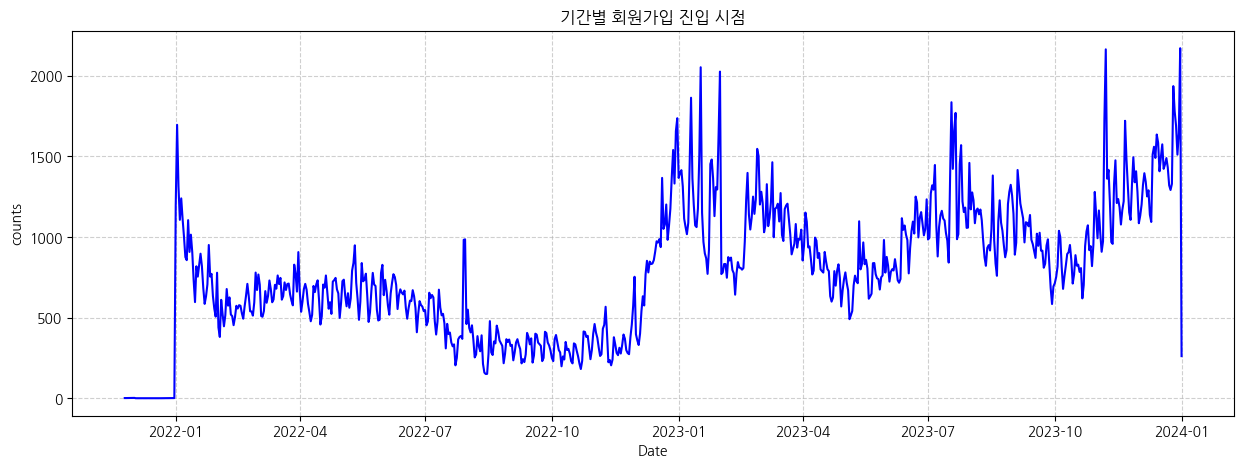

In [15]:
# 한글 폰트 설정 (환경에 맞게 주석 해제하여 사용)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. Polars를 활용한 날짜별 집계 (Pandas의 value_counts().sort_index() 대체)
daily_signup_enters = (
    enter_signup_page_kr
    # client_event_time에서 날짜(Date)만 추출하여 새로운 컬럼 생성
    .with_columns(pl.col("client_event_time").dt.date().alias("event_date"))
    # 날짜별 그룹화 및 데이터 개수 카운트
    .group_by("event_date")
    .agg(pl.len().alias("counts"))
    # 시간 순서대로 정렬
    .sort("event_date")
)

# 2. Matplotlib 시각화
plt.figure(figsize=(15, 5))
# Polars Series를 그대로 plt.plot에 전달 가능
plt.plot(
    daily_signup_enters["event_date"], 
    daily_signup_enters["counts"], 
    linestyle='-', 
    color='b'
)
plt.title('기간별 회원가입 진입 시점')
plt.ylabel('counts')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6) # 추세를 보기 쉽게 그리드 추가
plt.show()

- 주말과 주중의 주기가 존재하는듯?
- 피크치는 기간에는 특정 프로모션을 했던것이 아닌가 추측 해볼 수 있음

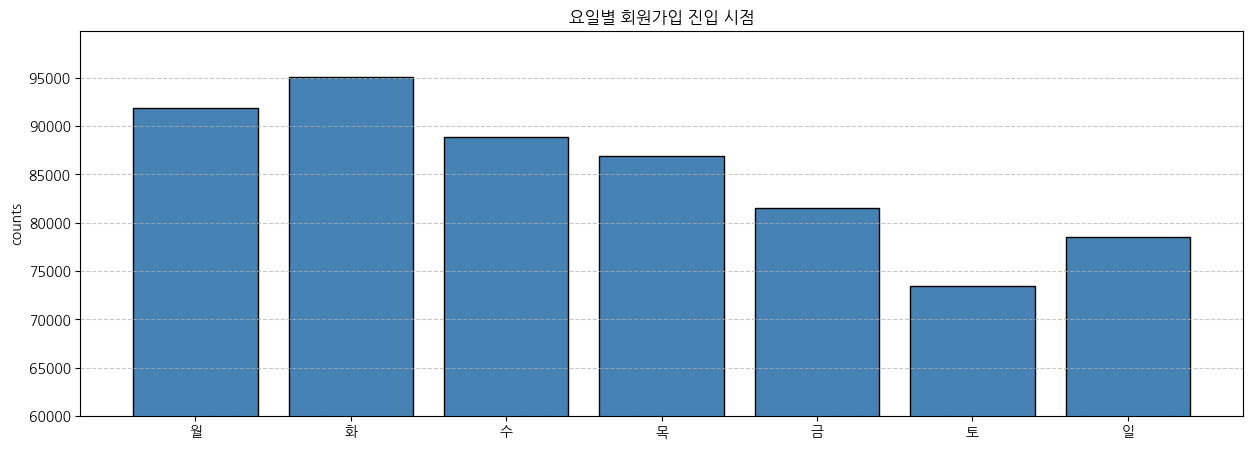

In [16]:
# 1. Polars를 활용한 요일별 집계
# 주의: Polars의 dt.weekday()는 1(월) ~ 7(일)을 반환합니다.
weekday_signup = (
    enter_signup_page_kr
    .with_columns(pl.col("client_event_time").dt.weekday().alias("weekday"))
    .group_by("weekday")
    .agg(pl.len().alias("counts"))
    .sort("weekday")
)

# 2. Matplotlib 시각화 (Bar chart)
plt.figure(figsize=(15, 5))

# X축 라벨을 숫자가 아닌 직관적인 요일명으로 변경 (선택 사항)
weekday_names = ['월', '화', '수', '목', '금', '토', '일']
x_labels = [weekday_names[i-1] for i in weekday_signup["weekday"]]

# 막대그래프 그리기
plt.bar(x_labels, weekday_signup["counts"], color='steelblue', edgecolor='black')

# y축 하한값 설정 (사용하신 plt.ylim(60000)을 더 명시적으로 작성)
plt.ylim(bottom=60000) 

# 제목은 '기간별' 대신 '요일별'이 더 적합해 보여서 살짝 수정했습니다.
plt.title('요일별 회원가입 진입 시점') 
plt.ylabel('counts')
plt.grid(axis='y', linestyle='--', alpha=0.7) # y축 기준 그리드 추가로 가독성 향상
plt.show()

토요일이 가장 낮은 가입진입
- 국가별로 시차 확인
- web 서비스이기 때문에 모바일 기종으로 가입하는 경우는 낮을 것이라 추측 -> 확인필요
- 데스크탑 vs 모바일의 다양한 기준으로 특성 차이 비교해보기

# complete.signup
- 회원가입 완료

| 테이블명                                                | 테이블 설명                        | 컬럼명             | 타입     | 컬럼 설명                | 비고                                         |
|:--------------------------------------------------------|:-----------------------------------|:-------------------|:---------|:-------------------------|:---------------------------------------------|
|  **complete.signup**                                     | 회원가입 완료                      | type              | object   | 로그인 방식             | -                                           |

In [17]:
complete_signup_kr = preprocess_korea_data('complete_signup.parquet')

🚀 [complete_signup.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌───────────────┬───────┐
│ country       ┆ len   │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│               ┆ 99377 │
│ South Korea   ┆ 45306 │
│ United States ┆ 120   │
│ Japan         ┆ 91    │
│ Canada        ┆ 43    │
│ Vietnam       ┆ 23    │
│ Australia     ┆ 12    │
│ Germany       ┆ 11    │
│ Hong Kong     ┆ 10    │
│ Netherlands   ┆ 10    │
└───────────────┴───────┘
=== 전처리 완료: complete_signup.parquet ===
총 데이터 수: 145133행 (중복 제거 완료)
--------------------------------------------------


In [18]:
complete_signup_kr_summary = profile_dataframe(complete_signup_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (145133, 13)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-01-01 09:06:31 ┆ 2024-01-01 08:51:54 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (13, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 100359     ┆ 69.15       ┆ 544      ┆ Seoul            

68%의 결측치가 일정하게 존재하는 경우들이 있다. 이는 시스템상의 업데이트로 수집 시작한 기간이 달라 발생했을 것이라 유추

<Figure size 1000x300 with 0 Axes>

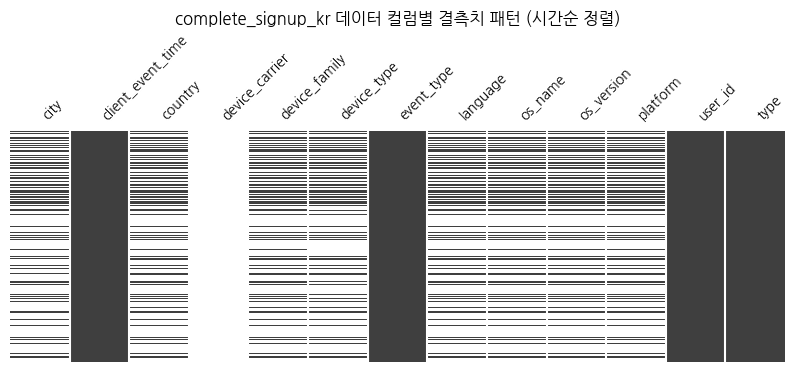

In [19]:
# 한글 폰트 설정 (환경에 맞게 주석 해제하여 사용하세요)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

sorted_signup_pd = (
    complete_signup_kr
    .sort("client_event_time")
    .to_pandas() # missingno 사용을 위해 Pandas 변환 (필수)
)

# 3. missingno 시각화 (Pandas 데이터프레임 사용)
plt.figure(figsize=(10, 3)) # msno 내부 plt와 충돌 방지를 위해 빈 figure 생성

# 스파크라인을 제거하고, 글자 크기 조정
msno.matrix(
    sorted_signup_pd, 
    figsize=(10, 3), # msno 내부에 figsize 다시 명시 
    fontsize=10, 
    sparkline=False
)

# y축 눈금 제거 및 제목 설정 (user 가 요청한 verbatim 유지하되 .csv 만 수정)
plt.title('complete_signup_kr 데이터 컬럼별 결측치 패턴 (시간순 정렬)')
plt.yticks([]) 
plt.show()

- 특정기간대에 결측치가 발생하는 것은 아님
- 결측치가 있는 행은 대체로 같은 컬럼들에서 켤측치를 가진다

In [20]:
type_counts = complete_signup_kr["type"].value_counts(sort=True)
print("=== 회원가입 완료 type 분포 ===")
print(type_counts)

=== 회원가입 완료 type 분포 ===
shape: (7, 2)
┌──────────┬───────┐
│ type     ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ kakao    ┆ 89484 │
│ google   ┆ 21465 │
│ naver    ┆ 19440 │
│ email    ┆ 14126 │
│ facebook ┆ 442   │
│ null     ┆ 175   │
│ test     ┆ 1     │
└──────────┴───────┘


가입 경로를 확인해봤을 때, 카카오,네이버가 많다 -> 대한민국 대상 서비스
- 회원가입 시점과 비교해보기
- 국가정보도 확ㅇ니해보기~

In [21]:
type_counts = complete_signup_kr["type"].value_counts(sort=True)
print("=== 회원가입 완료 type 분포 ===")
print(type_counts)

=== 회원가입 완료 type 분포 ===
shape: (7, 2)
┌──────────┬───────┐
│ type     ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ kakao    ┆ 89484 │
│ google   ┆ 21465 │
│ naver    ┆ 19440 │
│ email    ┆ 14126 │
│ facebook ┆ 442   │
│ null     ┆ 175   │
│ test     ┆ 1     │
└──────────┴───────┘


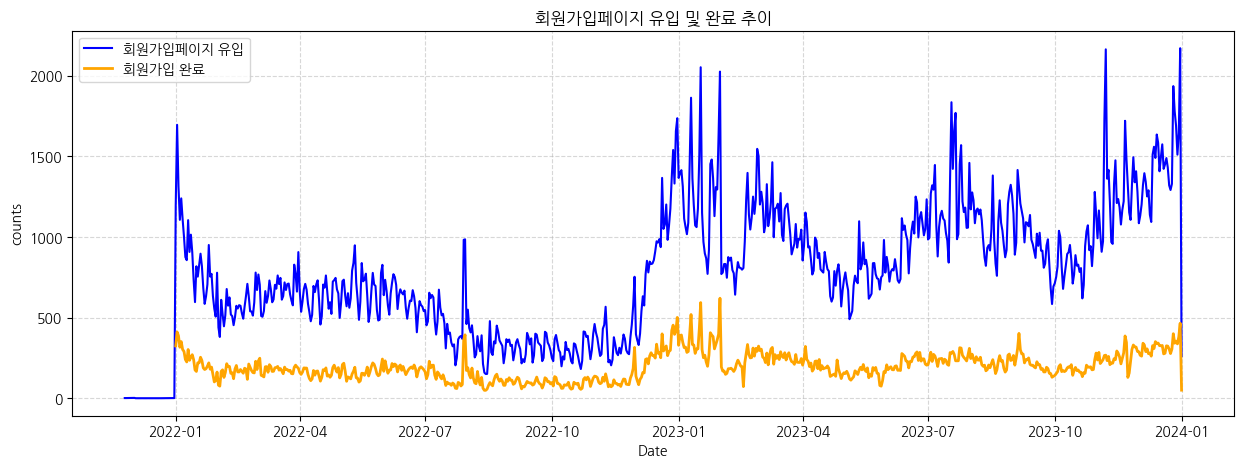

In [22]:
# 1. 회원가입 페이지 진입 일자별 집계
daily_enter = (
    enter_signup_page_kr
    .with_columns(pl.col("client_event_time").dt.date().alias("date"))
    .group_by("date")
    .agg(pl.len().alias("enter_cnt"))
    .sort("date")
)

# 2. 회원가입 완료 일자별 집계
daily_signup = (
    complete_signup_kr
    .with_columns(pl.col("client_event_time").dt.date().alias("date"))
    .group_by("date")
    .agg(pl.len().alias("complete_cnt"))
    .sort("date")
)

# 3. Matplotlib 시각화
plt.figure(figsize=(15, 5))

# 유입 트래픽 라인
plt.plot(
    daily_enter["date"], 
    daily_enter["enter_cnt"], 
    label='회원가입페이지 유입', 
    color='blue'
)

# 완료 트래픽 라인
plt.plot(
    daily_signup["date"], 
    daily_signup["complete_cnt"], 
    label='회원가입 완료', 
    color='orange',
    linewidth=2 # 완료 라인을 조금 더 강조
)

plt.legend()
plt.title('회원가입페이지 유입 및 완료 추이')
plt.xlabel('Date')
plt.ylabel('counts')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

추세는 얼추 비슷해 보인다. 실질적인 비율 상의 차이가 있는지 확인해볼 필요가 있다.
- 유입인원 대비 가입인원을 하나의 지표로 두고 기간별 차이가 있는지 확인해볼만함
- 유입인원은 튀는데 (eg. 23년 11월쯤?) 가입완료는 적은 경우

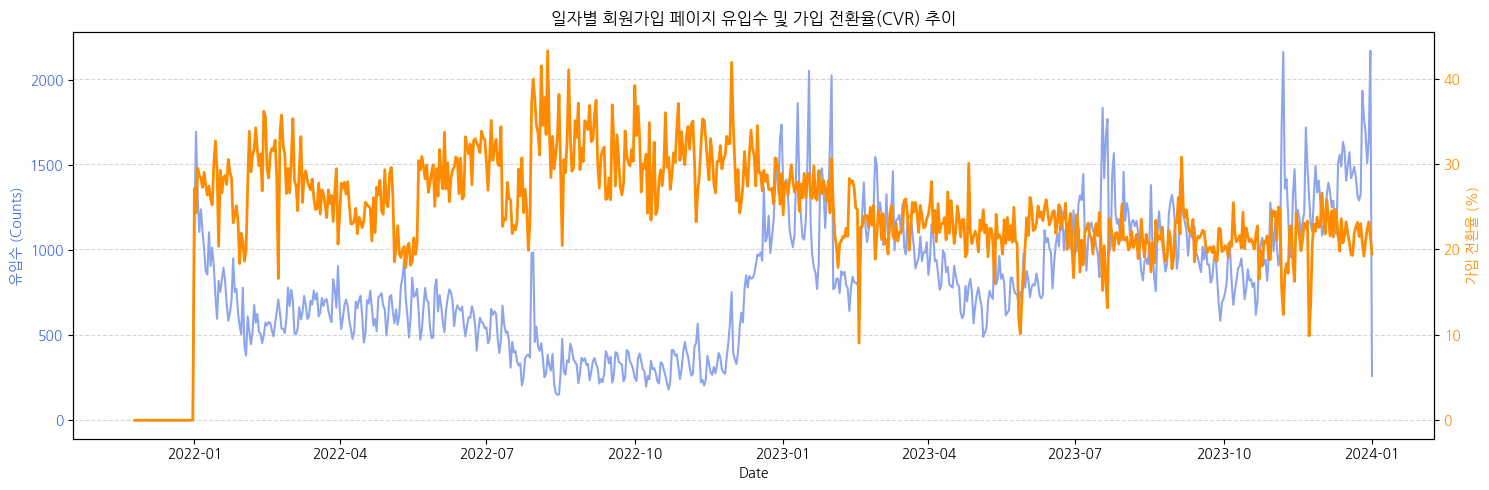

In [23]:
# 데이터 조인 및 전환율(CVR) 계산
cvr_df = (
    daily_enter
    .join(daily_signup, on="date", how="left")
    # 결측치(가입 완료가 0건인 날)를 0으로 채움
    .fill_null(0)
    # 전환율(%) 계산: (완료수 / 유입수) * 100
    .with_columns(
        (pl.col("complete_cnt") / pl.col("enter_cnt") * 100).alias("cvr_pct")
    )
    .sort("date")
    # Pandas 변환 전 데이터 확인용 (선택)
    # .to_pandas() 
)

# --- 시각화 (이중 축 그래프) ---
# Polars DataFrame을 Pandas로 변환하여 Matplotlib에 전달
df_viz = cvr_df.to_pandas()

fig, ax1 = plt.subplots(figsize=(15, 5))

# 첫 번째 축 (왼쪽 Y축): 유입수 (파란색 영역/선)
color1 = 'royalblue'
ax1.set_xlabel('Date')
ax1.set_ylabel('유입수 (Counts)', color=color1)
ax1.plot(df_viz["date"], df_viz["enter_cnt"], color=color1, alpha=0.6, label='페이지 유입')
ax1.tick_params(axis='y', labelcolor=color1)

# 두 번째 축 (오른쪽 Y축): 가입 전환율 (주황색 선)
ax2 = ax1.twinx() 
color2 = 'darkorange'
ax2.set_ylabel('가입 전환율 (%)', color=color2)
ax2.plot(df_viz["date"], df_viz["cvr_pct"], color=color2, linewidth=2, label='전환율(CVR)')
ax2.tick_params(axis='y', labelcolor=color2)

# 그래프 Y축 범위 설정 (전환율이 보통 10~30% 내외라면 상황에 맞게 상한선을 50 등으로 조절)
# ax2.set_ylim(0, 50) 

plt.title('일자별 회원가입 페이지 유입수 및 가입 전환율(CVR) 추이')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [24]:
complete_signup_kr['user_id'].value_counts(sort=True)

user_id,count
str,u32
"""041802e17eda4bea4ed569abe167ff6d""",1
"""338802850390a994f61cffb0e76c00a0""",1
"""0e768779c1c3240de73fdf4b75cae5e6""",1
"""d8f26ab41057769ada343c25bb5d6a0e""",1
"""e261df83c7ecd3535a2712e2b829c173""",1
"""6d0a10f5c2fb5d7eb1eca5fadd94e282""",1
"""d46d6ca0e46ac52244733e61b55e5752""",1
"""a8a2e166fc42adcf2de24c4d1507c7df""",1
"""ea867921dea994df41ee802b59dae236""",1


모든 User_id는 고유값을 가진다 -> 하나의 id는 1개의 회원 id값을 가짐

# enter.content_page
- 콘텐츠 개별 페이지 진입

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **enter.content_page**                              | 콘텐츠 개별 페이지 진입                 | content.id         | object | 콘텐츠 id                                       | -    |

In [25]:
enter_content_page_kr = preprocess_korea_data('enter_content_page.parquet')

🚀 [enter_content_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬─────────┐
│ country        ┆ len     │
│ ---            ┆ ---     │
│ str            ┆ u32     │
╞════════════════╪═════════╡
│ South Korea    ┆ 1864218 │
│ United States  ┆ 13912   │
│                ┆ 7570    │
│ Japan          ┆ 6984    │
│ Germany        ┆ 3858    │
│ Canada         ┆ 3504    │
│ Australia      ┆ 1511    │
│ Vietnam        ┆ 1415    │
│ United Kingdom ┆ 1377    │
│ Singapore      ┆ 1030    │
└────────────────┴─────────┘
=== 전처리 완료: enter_content_page.parquet ===
총 데이터 수: 1912039행 (중복 제거 완료)
--------------------------------------------------


In [26]:
enter_content_page_kr_summary = profile_dataframe(enter_content_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (1912039, 13)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-04 04:15:12 ┆ 2024-01-01 08:59:19 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (13, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 30462      ┆ 1.59        ┆ 1867     ┆ Seoul           

- 유저 결측치가 25% 존재한다. 이를 어떻게 해석해야할지? 회원가입안한 유저가 컨텐츠에 속하게된건가
- 전체행은 191만행이다. 이중 유니크 유저는 7.2만으로 한 유저가 여러 컨텐츠에 포함이 되어 있을 것이다
- 전체 컨텐츠는 208개이다.
    - 컨텐츠는 처음부터 모두 존재했을지? 아니면 특정시기부터 시작되었을지 확인할 필요가 있다.
- 인기있는 컨텐츠는 무엇인지 확인해보기

In [27]:
enter_content_page_kr['user_id'].value_counts(sort=True).head(10)

user_id,count
str,u32
null,463118
"""4f74b6e2f650f4c8db87579e44f5b7d6""",29654
"""d21dc741fde11ffb6768d8bdb3547398""",24270
"""e9261fd1140ae566bddb38c7a4c997cc""",2151
"""2d9b821bb7ad4ae411fc3eab9c0ebfe5""",1992
"""d3b2f51ede04364bd9861f8d261f26ec""",1912
"""57542a51e6d83e2a11fd6f35224067d7""",1874
"""4df798090ee2831f81ea5c60dfa15ad3""",1771
"""681d58f5654892f6d79438751dee2b2d""",1718


상위 2개 유저는 다른 유저 대비해서 상당히 많은 컨텐츠 접근이 있었다.
- 헤비유저 or 개발진 or 내부 공용아이디일 수 있다

In [28]:
# [Block-by-Block] 특정 헤비 유저의 행동 정밀 분석
target_user = "4f74b6e2f650f4c8db87579e44f5b7d6"

user_behavior = enter_content_page_kr.filter(pl.col("user_id") == target_user).sort("client_event_time")

# 1. 이벤트 간 시간 차이(초) 계산 및 통계
user_behavior_diff = user_behavior.with_columns([
    (pl.col("client_event_time").diff().dt.total_seconds()).alias("time_diff_sec")
])

print(f"=== 유저 {target_user[:8]}... 의 진입 간격 통계 ===")
print(user_behavior_diff.select([
    pl.col("time_diff_sec").mean().alias("평균_간격_초"),
    pl.col("time_diff_sec").median().alias("중앙값_간격_초"),
    pl.col("content.id").n_unique().alias("조회_컨텐츠_종류_수")
]))

# 2. 이 유저가 가장 많이 본 컨텐츠 TOP 5
print("\n=== 해당 유저의 최다 조회 컨텐츠 ===")
print(user_behavior.group_by("content.id").len().sort("len", descending=True).head(5))

=== 유저 4f74b6e2... 의 진입 간격 통계 ===
shape: (1, 3)
┌──────────────┬────────────────┬─────────────────────┐
│ 평균_간격_초 ┆ 중앙값_간격_초 ┆ 조회_컨텐츠_종류_수 │
│ ---          ┆ ---            ┆ ---                 │
│ f64          ┆ f64            ┆ u32                 │
╞══════════════╪════════════════╪═════════════════════╡
│ 1731.553468  ┆ 58.0           ┆ 6                   │
└──────────────┴────────────────┴─────────────────────┘

=== 해당 유저의 최다 조회 컨텐츠 ===
shape: (5, 2)
┌──────────────────────────────────┬───────┐
│ content.id                       ┆ len   │
│ ---                              ┆ ---   │
│ str                              ┆ u32   │
╞══════════════════════════════════╪═══════╡
│ 595cb4bbfc83e683b0314ca1312cfbde ┆ 22627 │
│ f491517f4737a60d661cd1fcacc702c0 ┆ 3345  │
│ f4be1a0fe0e301b03115591777fddf29 ┆ 3081  │
│ b314d5aba64a0aab40602cb72a4a1504 ┆ 599   │
│ 4641438a6c81ef572d997dbdc9100f8b ┆ 1     │
└──────────────────────────────────┴───────┘


동일한 컨텐츠에 대해 10분간격으로 로그가 계속 남는다     
- 동일한 컨텐츠에 계속 유입되는 이유가 무엇인지 확인 불가 (아마 개발자 디버그?)
- 이상치로 봐도 될듯
- 동일한 컨텐츠에 지속적으로 로그를 남기는 시스템인지도 확인이 필요하다

### 이상치(99분위수) 필터링

In [29]:
import polars as pl

# [Block-by-Block] 유저별 활동성 분포 분석
user_activity = enter_content_page_kr.group_by("user_id").agg([
    pl.len().alias("event_count")
]).sort("event_count", descending=True)

# 1. 상위 1% 유저의 활동량 확인 (이상치 임계값 결정용)
threshold_99 = user_activity.select(
    pl.col("event_count").quantile(0.99).alias("p99_threshold")
)

print("=== 유저별 이벤트 발생 수 분위수 ===")
print(user_activity.select([
    pl.col("event_count").mean().alias("평균"),
    pl.col("event_count").median().alias("중앙값"),
    pl.col("event_count").max().alias("최댓값")
]))
print(threshold_99)

# 2. (선택) 이상 유저를 제외한 순수 인기 컨텐츠 순위
# 예: p99 임계값을 넘는 유저는 분석에서 제외
p99_val = threshold_99.item()

enter_content_page_kr_clean = enter_content_page_kr.join(
    user_activity.filter(pl.col("event_count") <= p99_val),
    on="user_id",
    how="inner"
)

print(f"\n=== 상위 1% 헤비 유저 제외 후 인기 컨텐츠 TOP 5 ===")
print(enter_content_page_kr_clean.group_by("content.id").agg(
    pl.len().alias("count")
).sort("count", descending=True).head(5))

=== 유저별 이벤트 발생 수 분위수 ===
shape: (1, 3)
┌───────────┬────────┬────────┐
│ 평균      ┆ 중앙값 ┆ 최댓값 │
│ ---       ┆ ---    ┆ ---    │
│ f64       ┆ f64    ┆ u32    │
╞═══════════╪════════╪════════╡
│ 26.297867 ┆ 3.0    ┆ 463118 │
└───────────┴────────┴────────┘
shape: (1, 1)
┌───────────────┐
│ p99_threshold │
│ ---           │
│ f64           │
╞═══════════════╡
│ 269.0         │
└───────────────┘

=== 상위 1% 헤비 유저 제외 후 인기 컨텐츠 TOP 5 ===
shape: (5, 2)
┌──────────────────────────────────┬────────┐
│ content.id                       ┆ count  │
│ ---                              ┆ ---    │
│ str                              ┆ u32    │
╞══════════════════════════════════╪════════╡
│ f4be1a0fe0e301b03115591777fddf29 ┆ 104573 │
│ f491517f4737a60d661cd1fcacc702c0 ┆ 73137  │
│ 595cb4bbfc83e683b0314ca1312cfbde ┆ 51879  │
│ 61b6463287573f00de13a930805a52d6 ┆ 48880  │
│ b314d5aba64a0aab40602cb72a4a1504 ┆ 41412  │
└──────────────────────────────────┴────────┘


In [30]:
# 1. 로그인 유저(user_id가 있는 경우)만 필터링하여 빈도 계산
user_counts = enter_content_page_kr.filter(
    pl.col("user_id").is_not_null()
).group_by("user_id").agg(
    pl.len().alias("count")
)

# 2. Pandas의 value_counts().describe()와 동일한 요약 정보 출력
summary_stats = user_counts.select(pl.col("count")).describe()

print("=== [User Activity] 요약 통계 (Describe) ===")
print(summary_stats)

# 3. (추가) 상위 0.1% 유저가 전체 트래픽에서 차지하는 비중 확인
total_events = user_counts.select(pl.col("count").sum()).item()
top_01_percent_sum = user_counts.sort("count", descending=True).head(int(len(user_counts) * 0.01)).select(pl.col("count").sum()).item()

print(f"\n상위 1% 유저의 점유율: {(top_01_percent_sum / total_events * 100):.2f}%")

=== [User Activity] 요약 통계 (Describe) ===
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ count      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 72706.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ 19.928493  │
│ std        ┆ 155.088747 │
│ min        ┆ 1.0        │
│ 25%        ┆ 1.0        │
│ 50%        ┆ 3.0        │
│ 75%        ┆ 12.0       │
│ max        ┆ 29654.0    │
└────────────┴────────────┘

상위 1% 유저의 점유율: 28.01%


유저별로 콘텐츠 접속에 대한 분포는 중위수가 3건, 평균 19건이다. max 2.9만건은 특이케이스 같음 자세히 볼필요있음

In [31]:
# 1. user_id와 content.id 결측치 제거 후 유니크한 조합만 남기기 (중복 클릭 제거)
unique_reach = enter_content_page_kr.filter(
    pl.col("user_id").is_not_null() & pl.col("content.id").is_not_null()
).select(["user_id", "content.id"]).unique()

# 2. 컨텐츠별 유니크 유저 수 집계
content_reach_top10 = unique_reach.group_by("content.id").agg(
    pl.len().alias("unique_user_count")
).sort("unique_user_count", descending=True).head(10)

print("=== [Reach] 컨텐츠별 유니크 유저 수 TOP 10 ===")
print(content_reach_top10)

=== [Reach] 컨텐츠별 유니크 유저 수 TOP 10 ===
shape: (10, 2)
┌──────────────────────────────────┬───────────────────┐
│ content.id                       ┆ unique_user_count │
│ ---                              ┆ ---               │
│ str                              ┆ u32               │
╞══════════════════════════════════╪═══════════════════╡
│ f4be1a0fe0e301b03115591777fddf29 ┆ 30493             │
│ 61b6463287573f00de13a930805a52d6 ┆ 19057             │
│ f491517f4737a60d661cd1fcacc702c0 ┆ 15456             │
│ 595cb4bbfc83e683b0314ca1312cfbde ┆ 12475             │
│ b314d5aba64a0aab40602cb72a4a1504 ┆ 12063             │
│ c269eb6df3a374b464f7c18f12fa398f ┆ 11389             │
│ 68a3658f1b936bfff3bd6960cd561b0a ┆ 11380             │
│ d6227ba76134f6cf821bb98b5f235bd0 ┆ 8646              │
│ 7cebec6e79cc981dbf421c5ec2aedd9d ┆ 8157              │
│ db1819d3a7a4c4d85dccb3b9e982fbcd ┆ 6678              │
└──────────────────────────────────┴───────────────────┘


# click.content_page_start_content_button
- 콘텐츠 시청하기 버튼 클릭

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | content.id         | object | 콘텐츠 id                                       | -     |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button_name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 전   |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button.name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 후  |

In [32]:
click_content_page_start_content_button_kr = preprocess_korea_data('click_content_page_start_content_button.parquet')

🚀 [click_content_page_start_content_button.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬────────┐
│ country        ┆ len    │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ South Korea    ┆ 168403 │
│                ┆ 1416   │
│ United States  ┆ 911    │
│ Japan          ┆ 397    │
│ Canada         ┆ 342    │
│ Australia      ┆ 235    │
│ Germany        ┆ 192    │
│ Vietnam        ┆ 112    │
│ United Kingdom ┆ 86     │
│ Singapore      ┆ 74     │
└────────────────┴────────┘
=== 전처리 완료: click_content_page_start_content_button.parquet ===
총 데이터 수: 168587행 (중복 제거 완료)
--------------------------------------------------


In [33]:
click_content_page_start_content_button_kr_summary = profile_dataframe(click_content_page_start_content_button_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (168587, 15)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-26 03:40:51 ┆ 2024-01-01 08:51:15 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (15, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬────────────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                                   │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                                    │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                                    │
╞═══════════════════╪════════════╪═════════════╪══════════╪════════════════════════════════════════╡
│ city              ┆ 3391       ┆ 2.01        

In [113]:
CTA_contents_vcount = click_content_page_start_content_button_kr['content.id'].value_counts(sort=True)

print(CTA_contents_vcount)

shape: (166, 2)
┌──────────────────────────────────┬───────┐
│ content.id                       ┆ count │
│ ---                              ┆ ---   │
│ str                              ┆ u32   │
╞══════════════════════════════════╪═══════╡
│ 61b6463287573f00de13a930805a52d6 ┆ 32852 │
│ f4be1a0fe0e301b03115591777fddf29 ┆ 15822 │
│ f491517f4737a60d661cd1fcacc702c0 ┆ 10880 │
│ c269eb6df3a374b464f7c18f12fa398f ┆ 7130  │
│ 595cb4bbfc83e683b0314ca1312cfbde ┆ 5911  │
│ 68a3658f1b936bfff3bd6960cd561b0a ┆ 5468  │
│ b314d5aba64a0aab40602cb72a4a1504 ┆ 4553  │
│ db1819d3a7a4c4d85dccb3b9e982fbcd ┆ 3813  │
│ d6227ba76134f6cf821bb98b5f235bd0 ┆ 3588  │
│ 7cebec6e79cc981dbf421c5ec2aedd9d ┆ 3532  │
│ 445fac33232adcb3d1cdab7d8a579430 ┆ 3114  │
│ afe201c04b426366e0f8e9e2207c78c2 ┆ 3048  │
│ 621c7ad99b17d2d16832b618d47aea7e ┆ 2695  │
│ a914987711c7e2db9fd4bff7555ec87c ┆ 2658  │
│ 4641438a6c81ef572d997dbdc9100f8b ┆ 2422  │
│ …                                ┆ …     │
│ 040ccaa97a52e006a2c94bb7c5dce263 ┆ 2 

In [ ]:
click_content_page_start_content_button_kr.select('content.id' == None)

In [112]:
button_names_legacy = click_content_page_start_content_button_kr['button_name'].value_counts(sort=True)
button_names = click_content_page_start_content_button_kr['button.name'].value_counts(sort=True)

print(button_names_legacy)
print(button_names)

shape: (5, 2)
┌─────────────────┬────────┐
│ button_name     ┆ count  │
│ ---             ┆ ---    │
│ str             ┆ u32    │
╞═════════════════╪════════╡
│ null            ┆ 129764 │
│ 이어하기        ┆ 23743  │
│ 무료로 시작하기 ┆ 6042   │
│ 수강하기        ┆ 5323   │
│ 수강시작        ┆ 3715   │
└─────────────────┴────────┘
shape: (9, 2)
┌────────────────────┬───────┐
│ button.name        ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ null               ┆ 86287 │
│ 콘텐츠 구독하기    ┆ 39102 │
│ 콘텐츠 이어보기    ┆ 25908 │
│ 무료로 들어보기    ┆ 13406 │
│ 무료로 시작하기    ┆ 2510  │
│ 최저가 혜택 받기   ┆ 907   │
│ 최저가로 시작하기  ┆ 293   │
│ 구독 시작하기      ┆ 173   │
│ 할인받고 구독 시작 ┆ 1     │
└────────────────────┴───────┘


- 컨텐츠 시청하기 버튼의 경우 유니크 값이 165개이다. 컨텐츠 개별페이지 진입시 유니크값은 208개였는데 일부만 버튼이 있나? 싶음
- 유저id의 결측치는 25%이다.

<Figure size 1000x300 with 0 Axes>

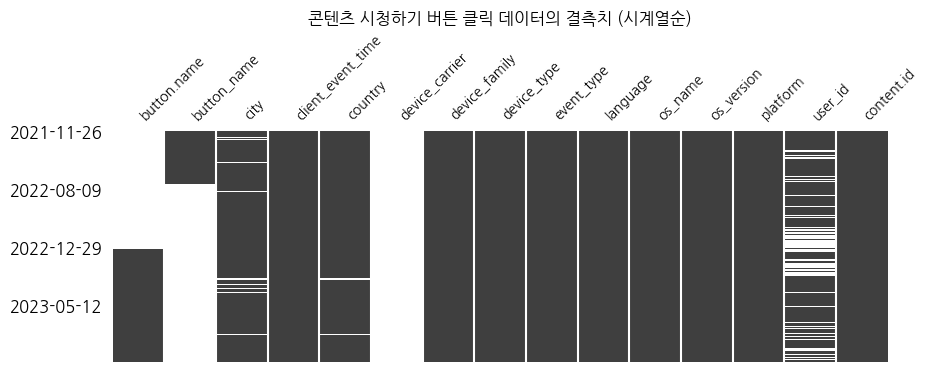

In [34]:
# 1. 시계열 정렬 및 컬럼 순서 변경
# 뒤의 2개 컬럼을 앞으로 가져오고 나머지를 붙입니다.
all_cols = click_content_page_start_content_button_kr.columns
reordered_cols = all_cols[-2:] + all_cols[:-2]

sort_df_pl = click_content_page_start_content_button_kr.sort("client_event_time").select(reordered_cols)
sort_df_pd = sort_df_pl.to_pandas()

# 2. 안전한 인덱스 추출 (데이터 길이에 맞춰 4개 지점 선정)
total_len = len(sort_df_pd)
if total_len > 0:
    # 0, 25%, 50%, 75% 지점의 인덱스를 정수로 계산 (마지막 인덱스는 total_len-1)
    safe_indices = [0, total_len // 4, total_len // 2, int(total_len * 0.75)]
    
    # 해당 인덱스의 날짜 라벨 생성
    date_labels = [sort_df_pd['client_event_time'].iloc[i].date() for i in safe_indices]

    # 3. 시각화
    plt.figure(figsize=(10, 3))
    # msno.matrix 내부에서 yticks를 건드리는 경우가 있어 ax를 명시적으로 받는 것이 안전합니다
    ax = msno.matrix(sort_df_pd, figsize=(10, 3), fontsize=10, sparkline=False)

    # 핵심: set_yticks로 위치를 먼저 고정하고 set_yticklabels로 라벨을 붙입니다
    ax.set_yticks(safe_indices)
    ax.set_yticklabels(date_labels, rotation=0)
    
    plt.title('콘텐츠 시청하기 버튼 클릭 데이터의 결측치 (시계열순)')
    plt.show()
else:
    print("⚠️ 데이터가 비어 있어 시각화를 진행할 수 없습니다.")

button.name의 경우 개편 후       
button_name의 경우 개편 전의 데이터를 나타낸다.    

대략 22년 5월부터 22년 12월까지는 관련 정보가 저장되어 있지 않다 -> 로그 기록이 없었던 듯

In [35]:
click_content_page_start_content_button_kr['button.name'].unique()

button.name
str
"""구독 시작하기"""
null
"""최저가로 시작하기"""
"""콘텐츠 이어보기"""
"""최저가 혜택 받기"""
"""할인받고 구독 시작"""
"""무료로 들어보기"""
"""콘텐츠 구독하기"""
"""무료로 시작하기"""


In [36]:
click_content_page_start_content_button_kr['button_name'].unique()

button_name
str
"""이어하기"""
null
"""수강시작"""
"""수강하기"""
"""무료로 시작하기"""


버튼은 각유저의 활성상태에 따른 이름 차이가 존재한다.

# click.content_page_more_review_button
- 콘텐츠 후기 더보기 버튼 클릭

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | content.id         | object | 콘텐츠 id                                       | -     |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button_name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 전   |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button.name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 후  |

In [37]:
click_content_page_more_review_button_kr = preprocess_korea_data('click_content_page_more_review_button.parquet')

🚀 [click_content_page_more_review_button.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌──────────────────────┬───────┐
│ country              ┆ len   │
│ ---                  ┆ ---   │
│ str                  ┆ u32   │
╞══════════════════════╪═══════╡
│ South Korea          ┆ 93527 │
│ Australia            ┆ 173   │
│ United States        ┆ 77    │
│ United Arab Emirates ┆ 42    │
│ Japan                ┆ 36    │
│ Germany              ┆ 25    │
│                      ┆ 18    │
│ France               ┆ 13    │
│ United Kingdom       ┆ 11    │
│ Vietnam              ┆ 9     │
└──────────────────────┴───────┘
=== 전처리 완료: click_content_page_more_review_button.parquet ===
총 데이터 수: 19407행 (중복 제거 완료)
--------------------------------------------------


In [38]:
click_content_page_more_review_button_kr_summary = profile_dataframe(click_content_page_more_review_button_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (19407, 13)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-12-14 17:38:04 ┆ 2024-01-01 03:44:14 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (13, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬───────────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                                  │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                                   │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                                   │
╞═══════════════════╪════════════╪═════════════╪══════════╪═══════════════════════════════════════╡
│ city              ┆ 170        ┆ 0.88        ┆ 276 

- 유져 아이디가 88% 결측치
    - 로그인 하지 않은 상태일 때 후기를 많이 살펴본다는 의미?
    - Chrome Headless는 크롤러로 볼 수 있다.
    - 후기 수집 크롤러 ㅜㅅㅜ 나빠요

In [39]:
# 1. 'Chrome Headless' 필터링 및 날짜 추출
# client_event_time에서 날짜(date)만 뽑아내어 그룹화합니다.
headless_daily_counts = (
    click_content_page_more_review_button_kr
    .filter(pl.col("os_name") == "Chrome Headless")
    .with_columns(
        pl.col("client_event_time").dt.date().alias("event_date")
    )
    .group_by("event_date")
    .agg(pl.len().alias("count"))
    .sort("event_date")
)

# 2. 결과 출력 (상위 30행 설정 적용 상태)
print("=== [Bot Detection] Chrome Headless 일별 유입 횟수 ===")
print(headless_daily_counts)

# 3. 전체 데이터 대비 비중 확인 (참고용)
total_count = click_content_page_more_review_button_kr.height
headless_total = headless_daily_counts.select(pl.col("count").sum()).item()

print(f"\n전체 클릭 중 Headless 비중: {(headless_total / total_count * 100):.2f}%")

=== [Bot Detection] Chrome Headless 일별 유입 횟수 ===
shape: (0, 2)
┌────────────┬───────┐
│ event_date ┆ count │
│ ---        ┆ ---   │
│ date       ┆ u32   │
╞════════════╪═══════╡
└────────────┴───────┘

전체 클릭 중 Headless 비중: 0.00%


3일동안 크롤러의 데이터가 로그의 50%정도의 비율로 존재

# enter.payment_page

결제 페이지 진입


| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **enter.payment_page**                              | 결제 페이지 진입                        | -                  | -      | -                                                | -        |

In [40]:
enter_payment_page_kr = preprocess_korea_data('enter_payment_page.parquet')

🚀 [enter_payment_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬────────┐
│ country        ┆ len    │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ South Korea    ┆ 162367 │
│ United States  ┆ 768    │
│ Japan          ┆ 345    │
│ Canada         ┆ 275    │
│                ┆ 162    │
│ Australia      ┆ 152    │
│ Germany        ┆ 109    │
│ Singapore      ┆ 86     │
│ United Kingdom ┆ 85     │
│ Vietnam        ┆ 79     │
└────────────────┴────────┘
=== 전처리 완료: enter_payment_page.parquet ===
총 데이터 수: 144514행 (중복 제거 완료)
--------------------------------------------------


In [41]:
enter_payment_page_kr_summary = profile_dataframe(enter_payment_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (144514, 12)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-11-03 11:39:46 ┆ 2023-12-10 23:56:01 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (12, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 2381       ┆ 1.65        ┆ 779      ┆ Seoul            

- 관련 로그가 22년 11월 부터 수집 / 다른 대부분 데이터는 21년도부터 있어서 연결해서 살펴보기 어려운 부분이 있음, 데이터들의 공통된 시간대를 살펴보는것 필요할듯
- 결제 완료 데이터와 묶어서 결제 페이지 이탈율을 확인 해볼 수 있음
- 같은 유저가 반복적으로 결제페이지를 들어갔다면 결제 오류 or 결제 갈등(?) or 개발자..

In [42]:
enter_payment_page_kr['user_id'].value_counts(sort=True).head(10)

user_id,count
str,u32
null,5266
"""233094e3798cb9f681d9d1466e276ed8""",101
"""d3b2f51ede04364bd9861f8d261f26ec""",53
"""06536039eaf41ade42390ee91f5f2f5b""",49
"""29126bff58f932e3b36adef464f8fdbb""",49
"""23380fbcdeecb36c1ad92a7558315b63""",45
"""521c1cc2d85a49c74f68b5773b1c5fcc""",42
"""fe3beafec5633844a56822e010bf73f9""",42
"""3767d4c7a827422fccf61d45ae889669""",40


In [43]:
# max 유저
# 일단위로 결제페이지를 들락날락 -> QA인듯
target_user_id = '233094e3798cb9f681d9d1466e276ed8'

result = (
    enter_payment_page_kr
    .filter(pl.col("user_id") == target_user_id)
    .sort("client_event_time")
    .head(30)
)

print(result)

shape: (30, 12)
┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ city   ┆ client ┆ countr ┆ devic ┆ devic ┆ devic ┆ event ┆ langu ┆ os_na ┆ os_ve ┆ platf ┆ user_ │
│ ---    ┆ _event ┆ y      ┆ e_car ┆ e_fam ┆ e_typ ┆ _type ┆ age   ┆ me    ┆ rsion ┆ orm   ┆ id    │
│ str    ┆ _time  ┆ ---    ┆ rier  ┆ ily   ┆ e     ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│        ┆ ---    ┆ str    ┆ ---   ┆ ---   ┆ ---   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   ┆ str   │
│        ┆ dateti ┆        ┆ str   ┆ str   ┆ str   ┆       ┆       ┆       ┆       ┆       ┆       │
│        ┆ me[μs] ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
╞════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ Asan   ┆ 2022-1 ┆ South  ┆ null  ┆ Windo ┆ Windo ┆ enter ┆ Korea ┆ Chrom ┆ 108.0 ┆ Web   ┆ 23309 │
│        ┆ 2-10   ┆ Korea  ┆       ┆ ws    ┆ ws    ┆ .paym ┆ n     ┆ e     

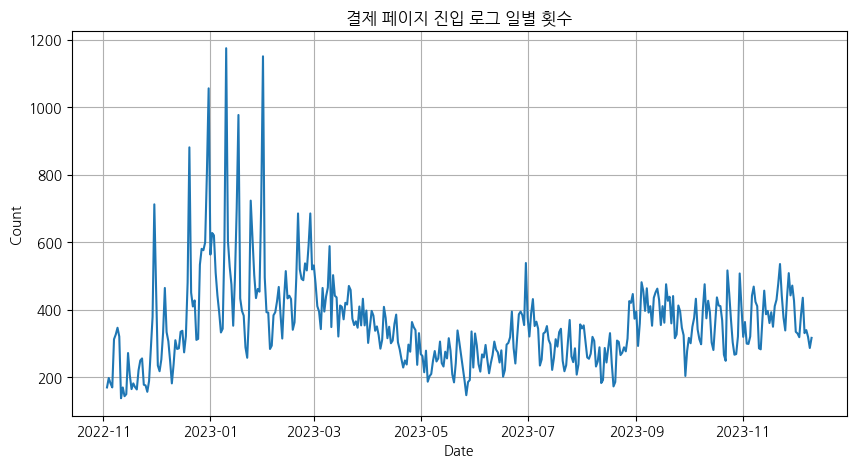

In [44]:
daily_counts = (
    enter_payment_page_kr
    .group_by(
        # 연산 결과에 별칭(alias)을 주어 컬럼명을 유지시킵니다.
        pl.col("client_event_time").dt.truncate("1d")
    )
    .agg(
        pl.len().alias("count")
    )
    .sort("client_event_time") # 이제 이 이름으로 정렬이 가능합니다.
)

# 시각화 부분은 동일
pd_daily_counts = daily_counts.to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(pd_daily_counts['client_event_time'], pd_daily_counts['count'], linestyle='-')
plt.title('결제 페이지 진입 로그 일별 횟수')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(True)
plt.show()

23년 2,3분기에 상대적으로 떨어짐 / 다른기간이 프로모션등이 있었는지 확인필요

# complete.subscription
- 첫 결제 완료
- 요금제 종류, 쿠폰 종류, 쿠폰 혜택 종류, 정상가, 할인가, 할인액, 결제수단 타입
- 첫 결제가 중복인 경우는 첫 결제 환불 후 다시 결제한 케이스로 간주


| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **complete.subscription**                         | 첫 결제 완료             | plan.price            | int64 | 정상가                                          | -|
| **complete.subscription**                         | 첫 결제 완료             | paid_amount           | int64 | 실제 결제 금액                                  | -|
| **complete.subscription**                         | 첫 결제 완료             | coupon.discount_amount | int64| 할인액                                          | 정상가 - 실제 결제 금액|
| **complete.subscription**                         | 첫 결제 완료             | pg.type               | object| 결제수단 타입                                   | A, B, C는 각기 다른 간편결제 수단|

In [45]:
complete_subscription_kr = preprocess_korea_data('complete_subscription.parquet')

🚀 [complete_subscription.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬───────┐
│ country        ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ South Korea    ┆ 13651 │
│                ┆ 383   │
│ United States  ┆ 69    │
│ Japan          ┆ 35    │
│ Canada         ┆ 20    │
│ Vietnam        ┆ 16    │
│ Australia      ┆ 16    │
│ United Kingdom ┆ 13    │
│ Netherlands    ┆ 11    │
│ Malaysia       ┆ 9     │
└────────────────┴───────┘
=== 전처리 완료: complete_subscription.parquet ===
총 데이터 수: 14246행 (중복 제거 완료)
--------------------------------------------------


In [46]:
complete_subscription_kr_summary = profile_dataframe(complete_subscription_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (14246, 16)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-01-01 15:17:25 ┆ 2024-01-01 01:27:37 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (16, 5)
┌────────────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column                 ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---                    ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str                    ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞════════════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city                   ┆ 532        ┆ 3.73        ┆

In [ ]:
fisrt_sub_paid_amount_vcount = complete_subscription_kr['plan.price'].value_counts(sort=True)

print(fisrt_sub_paid_amount_vcount)

shape: (41, 2)
┌─────────────┬───────┐
│ paid_amount ┆ count │
│ ---         ┆ ---   │
│ i64         ┆ u32   │
╞═════════════╪═══════╡
│ 15920       ┆ 5706  │
│ 131600      ┆ 1332  │
│ 79200       ┆ 1217  │
│ 95520       ┆ 853   │
│ 3960        ┆ 793   │
│ 42960       ┆ 743   │
│ 13532       ┆ 706   │
│ 83200       ┆ 565   │
│ 95200       ┆ 346   │
│ 87200       ┆ 334   │
│ 111860      ┆ 295   │
│ 36516       ┆ 252   │
│ 14328       ┆ 224   │
│ 91200       ┆ 221   │
│ 12736       ┆ 166   │
│ …           ┆ …     │
│ 127652      ┆ 7     │
│ 25776       ┆ 4     │
│ 41671       ┆ 4     │
│ 119756      ┆ 4     │
│ 125020      ┆ 4     │
│ 14805       ┆ 3     │
│ 14487       ┆ 3     │
│ 39952       ┆ 2     │
│ 9552        ┆ 2     │
│ 122388      ┆ 1     │
│ 19920       ┆ 1     │
│ 82000       ┆ 1     │
│ 11144       ┆ 1     │
│ 40812       ┆ 1     │
│ 39093       ┆ 1     │
└─────────────┴───────┘


- 22년 1월부터 23년 12월말까지 첫결제 데이터

In [47]:
mismatch_df = complete_subscription_kr.filter(
    (pl.col("plan.price") - pl.col("paid_amount")) != pl.col("coupon.discount_amount")
)

# 2. 행 개수 확인 (두 가지 방법 중 편한 것을 사용하세요)
mismatch_count = len(mismatch_df)  # 방법 1
# mismatch_count = mismatch_df.height  # 방법 2

print(f"결제 금액 불일치 건수: {mismatch_count}")

# 3. 만약 불일치 건수가 있다면 샘플 확인
if mismatch_count > 0:
    print(mismatch_df.select([
        "user_id", "plan.price", "paid_amount", "coupon.discount_amount"
    ]).head(5))

결제 금액 불일치 건수: 0


할인금액과 실제 결제 금액간의 차이가 존재하는 행은 없다

첫 결제가 중복인 경우는 첫 결제 환불 후 다시 결제한 케이스 확인해보기

In [48]:
multi_pay = (
    complete_subscription_kr
    .group_by("user_id")
    .agg(
        pl.len().alias("첫 결제 완료 횟수")
    )
    .filter(pl.col("첫 결제 완료 횟수") != 1) # 1회가 아닌(즉, 2회 이상) 유저만 필터링
    .sort("첫 결제 완료 횟수", descending=True) # 많이 결제한 순으로 정렬 (옵션)
)

print(multi_pay)

shape: (319, 2)
┌──────────────────────────────────┬───────────────────┐
│ user_id                          ┆ 첫 결제 완료 횟수 │
│ ---                              ┆ ---               │
│ str                              ┆ u32               │
╞══════════════════════════════════╪═══════════════════╡
│ 3767d4c7a827422fccf61d45ae889669 ┆ 8                 │
│ f833cca4c382ac8c502c6f99bc432725 ┆ 6                 │
│ ccea16701cf72a9027d7d5f2c3d3019c ┆ 5                 │
│ e04c24e899b1e875ed432a7b398a4308 ┆ 4                 │
│ 3b4f4a292895752991395bf3984ffe09 ┆ 3                 │
│ 9db1fecd41c7bfcf0b5158d5369f1f9c ┆ 3                 │
│ cb29e4a3dbd73f35c25ed1422b43928e ┆ 3                 │
│ 24102bc5428dc2911d2dae4682e907f7 ┆ 3                 │
│ a086991fab126bf4e393e5e18aff1075 ┆ 3                 │
│ a39392cc91f2643a80d6967199a904dd ┆ 3                 │
│ 1718432f54ebca48832fc7ee9a82810e ┆ 3                 │
│ d1082788eeb60ac21fec1e091b09c9ad ┆ 3                 │
│ f614cfe2171a6573b3c2

In [49]:
# 1. 재결제 유저 데이터 (multi_pay)
multi_pay = (
    complete_subscription_kr
    .group_by("user_id")
    .agg(pl.len().alias("pay_count"))
    .filter(pl.col("pay_count") > 1)
)

# 2. 통계치 계산
total_unique_users = complete_subscription_kr["user_id"].n_unique() # 전체 결제 유저 수
multi_pay_user_count = len(multi_pay)         # 2회 이상 결제 유저 수

# 3. 비율 계산 (Pandas 스타일 문장 재현)
ratio = (multi_pay_user_count / total_unique_users) * 100

print(f"전체 결제 유저 수: {total_unique_users}")
print(f"2회 이상 결제 발생 유저 수: {multi_pay_user_count}")
print(f"중복/재결제 유저 비율은 {round(ratio, 2)}% 입니다.")

전체 결제 유저 수: 13881
2회 이상 결제 발생 유저 수: 319
중복/재결제 유저 비율은 2.3% 입니다.


In [50]:
# 3767d4c7a827422fccf61d45ae889669 유저의 첫결제 완료 시점 살펴보기
target_user = 'ccea16701cf72a9027d7d5f2c3d3019c'

# 특정 유저의 결제 시간만 추출하여 정렬
user_payment_timeline = (
    complete_subscription_kr
    .filter(pl.col("user_id") == target_user)
    .select("client_event_time")
    .sort("client_event_time")
)

print(user_payment_timeline)

shape: (5, 1)
┌─────────────────────┐
│ client_event_time   │
│ ---                 │
│ datetime[μs]        │
╞═════════════════════╡
│ 2023-10-20 16:01:33 │
│ 2023-10-23 14:26:22 │
│ 2023-10-26 10:12:19 │
│ 2023-11-13 16:44:59 │
│ 2023-11-23 12:04:28 │
└─────────────────────┘


첫결제를 다수 진행한 유저는 첫 결제 시점이 넓은 기간에 걸쳐 존재한다.    
이러한 경우 구매 리텐션을 확인하는데 첫 구매시점을 어떤 시점으로 봐야하는지 어려움이 있을 수 있다.     
이런 유저를 제외하고 살펴볼지 포함하고 살펴볼지는 추가적인 분석작업을 통해 진행 해보길

In [51]:
# 유저별로 이전 결제와의 시간 차이(diff) 계산
pay_diff_analysis = (
    complete_subscription_kr
    .sort(["user_id", "client_event_time"])
    .with_columns([
        pl.col("client_event_time")
        .diff()
        .over("user_id")
        .alias("time_delta")
    ])
    .filter(pl.col("time_delta").is_not_null()) # 첫 번째 결제는 diff가 null이므로 제외
)

# 시간 차이를 '시간(hours)' 단위로 변환하여 통계 확인
print(
    pay_diff_analysis
    .select([
        (pl.col("time_delta").dt.total_seconds() / 3600).alias("diff_hours")
    ])
    .describe()
)

shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ diff_hours   │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 365.0        │
│ null_count ┆ 0.0          │
│ mean       ┆ 688.054203   │
│ std        ┆ 1964.45287   │
│ min        ┆ 0.000278     │
│ 25%        ┆ 0.617222     │
│ 50%        ┆ 23.651389    │
│ 75%        ┆ 504.691944   │
│ max        ┆ 17135.978889 │
└────────────┴──────────────┘


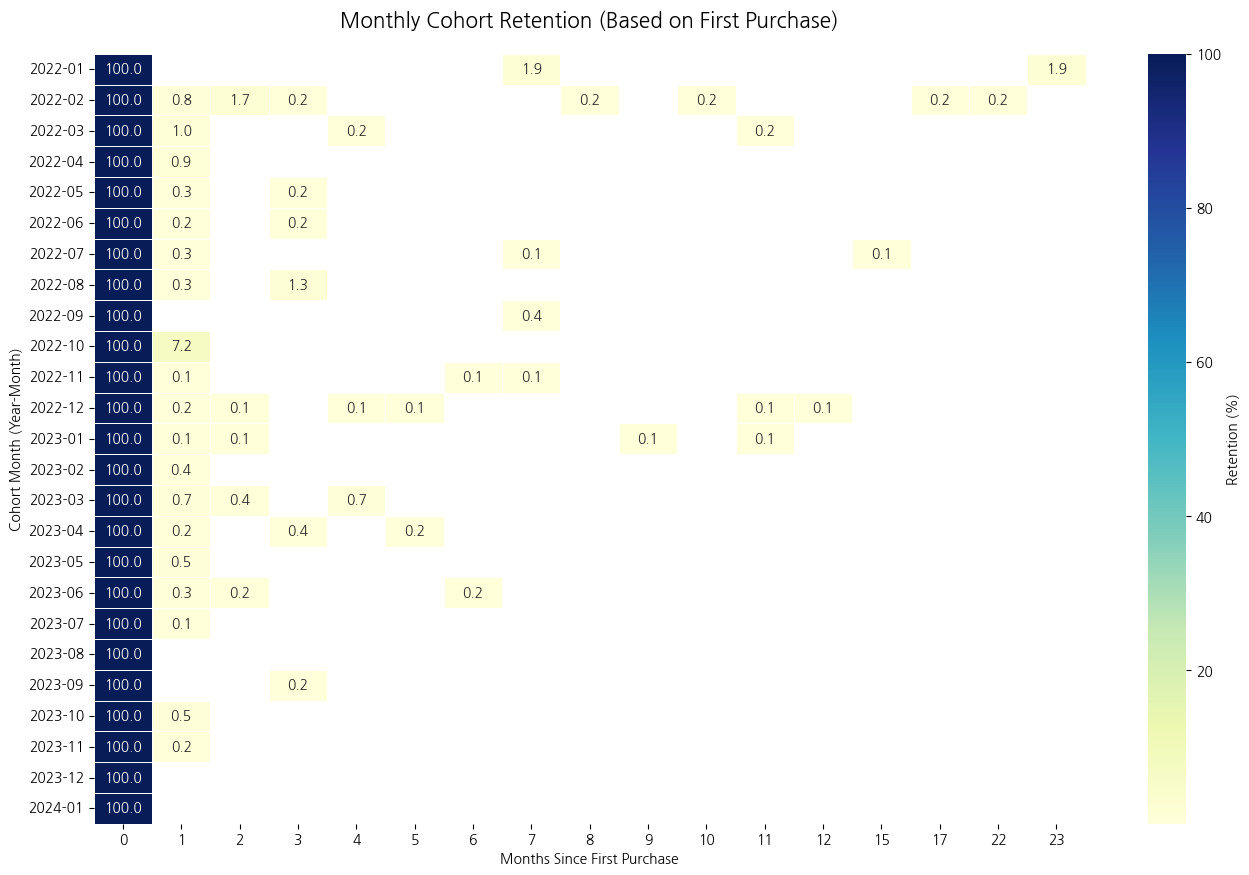

In [52]:
# 1. 코호트 계산 및 날짜 포맷팅 (문자열 변환으로 가독성 확보)
cs_cohort = complete_subscription_kr.with_columns([
    pl.col("client_event_time").min().over("user_id").dt.truncate("1mo").dt.to_string("%Y-%m").alias("cohort_month"),
    pl.col("client_event_time").dt.truncate("1mo").alias("order_month"),
    pl.col("client_event_time").min().over("user_id").dt.truncate("1mo").alias("cohort_month_raw")
])

# 2. 리텐션 데이터 집계
cohort_data = (
    cs_cohort
    .group_by(["cohort_month", "order_month", "cohort_month_raw"])
    .agg(pl.col("user_id").n_unique().alias("user_count"))
    .with_columns([
        ((pl.col("order_month").dt.year() - pl.col("cohort_month_raw").dt.year()) * 12 +
         (pl.col("order_month").dt.month() - pl.col("cohort_month_raw").dt.month())).alias("cohort_period")
    ])
    .sort(["cohort_month_raw", "cohort_period"])
)

# 3. 피벗 및 비율 계산
cohort_pivot = (
    cohort_data.to_pandas()
    .pivot(index="cohort_month", columns="cohort_period", values="user_count")
)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

# 4. 시각화 (날짜가 깔끔해진 버전)
plt.figure(figsize=(16, 10))
sns.heatmap(retention, annot=True, fmt=".1f", cmap="YlGnBu", 
            cbar_kws={'label': 'Retention (%)'}, linewidths=.5)
plt.title("Monthly Cohort Retention (Based on First Purchase)", fontsize=15, pad=20)
plt.ylabel("Cohort Month (Year-Month)")
plt.xlabel("Months Since First Purchase")
plt.show()

In [53]:
# 1. 유저별 첫 결제 정보 생성 (모수 확인용)
first_purchase_df = (
    complete_subscription_kr
    .group_by("user_id")
    .agg([
        pl.col("client_event_time").min().alias("first_time"),
        pl.col("device_family").first().alias("device"), # 첫 유입 기기
        pl.col("os_name").first().alias("os")            # 첫 유입 OS
    ])
    .with_columns(
        pl.col("first_time").dt.truncate("1mo").dt.to_string("%Y-%m").alias("cohort_month")
    )
)

# 2. 월별 신규 결제 유저 수(모수) 집계
cohort_size_check = (
    first_purchase_df
    .group_by("cohort_month")
    .agg(pl.len().alias("new_user_count"))
    .sort("cohort_month")
)

# 3. 2022-10 코호트 유저들의 상세 특성 (기기/OS 비중)
oct_22_users = (
    first_purchase_df
    .filter(pl.col("cohort_month") == "2022-10")
    .group_by(["device", "os"])
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)

print("--- [월별 신규 결제 유저 모수 확인] ---")
print(cohort_size_check)

print("\n--- [2022-10 코호트 유저 유입 특성] ---")
print(oct_22_users)

--- [월별 신규 결제 유저 모수 확인] ---
shape: (25, 2)
┌──────────────┬────────────────┐
│ cohort_month ┆ new_user_count │
│ ---          ┆ ---            │
│ str          ┆ u32            │
╞══════════════╪════════════════╡
│ 2022-01      ┆ 54             │
│ 2022-02      ┆ 531            │
│ 2022-03      ┆ 629            │
│ 2022-04      ┆ 529            │
│ 2022-05      ┆ 611            │
│ 2022-06      ┆ 581            │
│ 2022-07      ┆ 689            │
│ 2022-08      ┆ 379            │
│ 2022-09      ┆ 257            │
│ 2022-10      ┆ 194            │
│ 2022-11      ┆ 928            │
│ 2022-12      ┆ 1209           │
│ 2023-01      ┆ 1462           │
│ 2023-02      ┆ 255            │
│ 2023-03      ┆ 269            │
│ 2023-04      ┆ 447            │
│ 2023-05      ┆ 384            │
│ 2023-06      ┆ 656            │
│ 2023-07      ┆ 796            │
│ 2023-08      ┆ 520            │
│ 2023-09      ┆ 583            │
│ 2023-10      ┆ 364            │
│ 2023-11      ┆ 566            │
│ 202

# renew.subscription

- 정기 결제 완료

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **renew.subscription**                            | 정기 결제 완료           | plan.price            | int64 | 정상가                                          | -|
| **renew.subscription**                            | 정기 결제 완료           | paid_amount           | int64 | 실제 결제 금액                                  | -|
| **renew.subscription**                            | 정기 결제 완료           | coupon.discount_amount | int64| 할인액                                          | 정상가 - 실제 결제 금액|                              
| **renew.subscription**                            | 정기 결제 완료           | pg.type               | object| 결제수단 타입                                   | A, B, C는 각기 다른 간편결제 수단|

In [54]:
renew_subscription_kr = preprocess_korea_data('renew_subscription.parquet')

🚀 [renew_subscription.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬───────┐
│ country        ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ South Korea    ┆ 15100 │
│                ┆ 289   │
│ United States  ┆ 170   │
│ Japan          ┆ 85    │
│ Canada         ┆ 65    │
│ United Kingdom ┆ 36    │
│ Australia      ┆ 28    │
│ Germany        ┆ 25    │
│ Netherlands    ┆ 20    │
│ Singapore      ┆ 16    │
└────────────────┴───────┘
=== 전처리 완료: renew_subscription.parquet ===
총 데이터 수: 15945행 (중복 제거 완료)
--------------------------------------------------


In [55]:
renew_subscription_kr_summary = profile_dataframe(renew_subscription_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (15945, 16)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-09-08 12:05:02 ┆ 2024-01-01 01:10:03 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (16, 5)
┌────────────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column                 ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---                    ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str                    ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞════════════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city                   ┆ 370        ┆ 2.32        ┆

In [132]:
renew_paid_amount_vcount = renew_subscription_kr['plan.price'].value_counts(sort=True)

print(renew_paid_amount_vcount)

shape: (11, 2)
┌────────────┬───────┐
│ plan.price ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 15920      ┆ 11817 │
│ 42960      ┆ 1062  │
│ 79200      ┆ 954   │
│ 131600     ┆ 891   │
│ 95520      ┆ 537   │
│ 83200      ┆ 287   │
│ 87200      ┆ 160   │
│ 95200      ┆ 115   │
│ 91200      ┆ 105   │
│ 14328      ┆ 16    │
│ 118440     ┆ 1     │
└────────────┴───────┘


- pg.type은 결측치가 많아서 활용에 어려움이 있어보임
- 모든 정기 결제 고객은 첫구매 데이터가 존재하는지 확인필요
- 기간은 22년 9월부터 23년 12월말까지

In [56]:
import polars as pl

# 모든 정기 결제 고객의 첫 구매 데이터 존재 여부 확인
# cs(complete_subscription_kr)에 있는 유저와 rs에 있는 유저를 비교
cs_users = complete_subscription_kr.select("user_id").unique()
rs_users = renew_subscription_kr.select("user_id").unique()

# rs에는 있지만 cs에는 없는 '미확인 유저' 추출 (차집합, 검증용)
missing_first_purchase_users = rs_users.join(cs_users, on="user_id", how="anti")

# 결과 집계 및 출력
total_rs_users = len(rs_users)
missing_count = len(missing_first_purchase_users)
missing_ratio = (missing_count / total_rs_users) * 100

print(f"--- [데이터 무결성 체크: Renew vs First Purchase] ---")
print(f"전체 정기 결제 유저 수: {total_rs_users}명")
print(f"첫 구매 이력이 없는 갱신 유저 수: {missing_count}명")
print(f"결측 비율: {missing_ratio:.2f}%")

# 4. 기간별 갱신 추이 확인 (22년 9월 ~ 23년 12월)
renew_trend = (
    renew_subscription_kr
    .filter(
        (pl.col("client_event_time") >= datetime(2022, 9, 1)) &
        (pl.col("client_event_time") <= datetime(2023, 12, 31))
    )
    .group_by(pl.col("client_event_time").dt.truncate("1mo").alias("renew_month"))
    .agg(pl.len().alias("renew_count"))
    .sort("renew_month")
)

print("\n--- [월별 구독 갱신 추이] ---")
print(renew_trend)

--- [데이터 무결성 체크: Renew vs First Purchase] ---
전체 정기 결제 유저 수: 7498명
첫 구매 이력이 없는 갱신 유저 수: 2113명
결측 비율: 28.18%

--- [월별 구독 갱신 추이] ---
shape: (16, 2)
┌─────────────────────┬─────────────┐
│ renew_month         ┆ renew_count │
│ ---                 ┆ ---         │
│ datetime[μs]        ┆ u32         │
╞═════════════════════╪═════════════╡
│ 2022-09-01 00:00:00 ┆ 873         │
│ 2022-10-01 00:00:00 ┆ 1043        │
│ 2022-11-01 00:00:00 ┆ 882         │
│ 2022-12-01 00:00:00 ┆ 1751        │
│ 2023-01-01 00:00:00 ┆ 1232        │
│ 2023-02-01 00:00:00 ┆ 714         │
│ 2023-03-01 00:00:00 ┆ 463         │
│ 2023-04-01 00:00:00 ┆ 585         │
│ 2023-05-01 00:00:00 ┆ 664         │
│ 2023-06-01 00:00:00 ┆ 741         │
│ 2023-07-01 00:00:00 ┆ 909         │
│ 2023-08-01 00:00:00 ┆ 1099        │
│ 2023-09-01 00:00:00 ┆ 1210        │
│ 2023-10-01 00:00:00 ┆ 1187        │
│ 2023-11-01 00:00:00 ┆ 998         │
│ 2023-12-01 00:00:00 ┆ 1467        │
└─────────────────────┴─────────────┘


### 월별 신규 구독, 재구독 유저 수 시각화

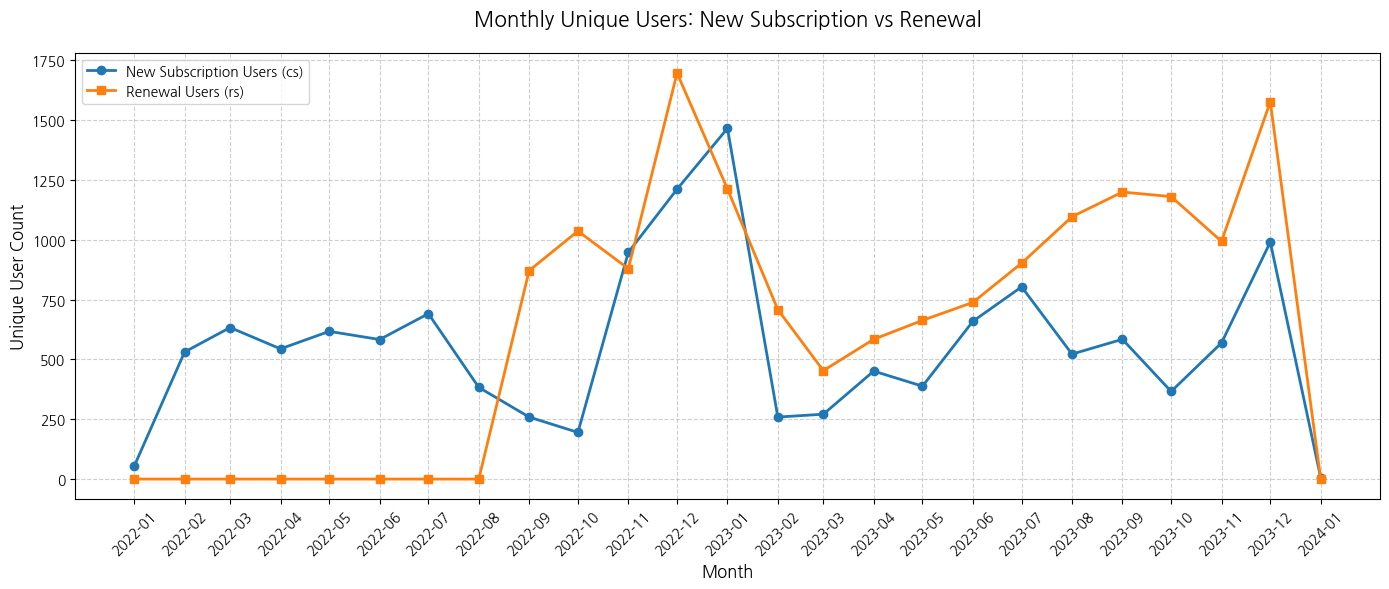

In [57]:
# 1. 월별 신규 구독 유저(cs) 집계
cs_monthly = (
    complete_subscription_kr
    .group_by(pl.col("client_event_time").dt.truncate("1mo").alias("month"))
    .agg(pl.col("user_id").n_unique().alias("new_sub_users"))
)

# 2. 월별 재구독 유저(rs) 집계
rs_monthly = (
    renew_subscription_kr
    .group_by(pl.col("client_event_time").dt.truncate("1mo").alias("month"))
    .agg(pl.col("user_id").n_unique().alias("renew_users"))
)

# 3. 두 데이터 조인 및 정렬
# (어느 한 쪽이 없는 달도 표시하기 위해 outer join 사용)
trend_data = (
    cs_monthly
    .join(rs_monthly, on="month", how="full")
    .sort("month")
    .fill_null(0) # 데이터가 없는 달은 0으로 채움
)

# 4. 시각화 (Matplotlib)
pd_trend = trend_data.to_pandas()

plt.figure(figsize=(14, 6))
plt.plot(pd_trend['month'], pd_trend['new_sub_users'], marker='o', label='New Subscription Users (cs)', color='#1f77b4', linewidth=2)
plt.plot(pd_trend['month'], pd_trend['renew_users'], marker='s', label='Renewal Users (rs)', color='#ff7f0e', linewidth=2)

plt.title('Monthly Unique Users: New Subscription vs Renewal', fontsize=15, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Unique User Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# x축 날짜 가독성 개선
plt.xticks(pd_trend['month'], [d.strftime('%Y-%m') for d in pd_trend['month']], rotation=45)

plt.tight_layout()
plt.show()

첫구매가 존재하는 재구매 인원만 필터하여 재구매 하는 유저의 특성을 그렇지 않은 유저들과 비교해서 살펴보면 좋을 듯
- 어떤 유저 특성을 가지는지
- 어떤 컨텐츠를 많이 소비 했는지
- 액티브 정도는 얼마나 되는지

In [58]:
# 1. 유니크 유저 풀 생성
all_cs_u_ids = complete_subscription_kr.select("user_id").unique()
all_rs_u_ids = renew_subscription_kr.select("user_id").unique()

# Group A: 재결제 유저 (첫 결제 기록이 있으면서 재결제도 한 유저)
repurchase_user_ids = all_rs_u_ids.join(all_cs_u_ids, on="user_id", how="inner")

# Group B: 단발성 유저 (첫 결제는 했으나, 재결제 기록은 전혀 없는 유저)
one_time_user_ids = all_cs_u_ids.join(all_rs_u_ids, on="user_id", how="anti")

# Group C: 결측된 유저 (재결제는 했으나, 첫 결제 기록은 전혀 없는 유저)
only_renewal_user_ids = all_rs_u_ids.join(all_cs_u_ids, on="user_id", how="anti")

print(f"--- [분석 대상 유저군 확정] ---")
print(f"재결제 유저 (Group A): {len(repurchase_user_ids):,}명")
print(f"단발성 유저 (Group B): {len(one_time_user_ids):,}명")
print(f"결측된 유저 (Group C): {len(only_renewal_user_ids):,}명")

--- [분석 대상 유저군 확정] ---
재결제 유저 (Group A): 5,385명
단발성 유저 (Group B): 8,496명
결측된 유저 (Group C): 2,113명


In [59]:
# 유저 프로필 추출 함수 (cs 테이블 기준)
def get_user_profile(target_ids, group_name):
    return (
        complete_subscription_kr.join(target_ids, on="user_id", how="inner")
        .group_by(["os_name", "device_family"])
        .agg(pl.len().alias("user_count"))
        .with_columns((pl.col("user_count") / pl.col("user_count").sum() * 100).round(1).alias("ratio(%)"))
        .sort("user_count", descending=True)
        .head(5)
        .with_columns(pl.lit(group_name).alias("Group"))
        .select(["Group", "os_name", "device_family", "user_count", "ratio(%)"])
    )

profile_a = get_user_profile(repurchase_user_ids, "A (재결제)")
profile_b = get_user_profile(one_time_user_ids, "B (단발성)")

print("--- [그룹별 주요 접속 환경 TOP 5] ---")
print(pl.concat([profile_a, profile_b]))

--- [그룹별 주요 접속 환경 TOP 5] ---
shape: (10, 5)
┌────────────┬───────────────┬───────────────┬────────────┬──────────┐
│ Group      ┆ os_name       ┆ device_family ┆ user_count ┆ ratio(%) │
│ ---        ┆ ---           ┆ ---           ┆ ---        ┆ ---      │
│ str        ┆ str           ┆ str           ┆ u32        ┆ f64      │
╞════════════╪═══════════════╪═══════════════╪════════════╪══════════╡
│ A (재결제) ┆ Chrome        ┆ Windows       ┆ 2574       ┆ 46.5     │
│ A (재결제) ┆ Chrome        ┆ Mac           ┆ 572        ┆ 10.3     │
│ A (재결제) ┆ Edge          ┆ Windows       ┆ 520        ┆ 9.4      │
│ A (재결제) ┆ Mobile Safari ┆ Apple iPhone  ┆ 366        ┆ 6.6      │
│ A (재결제) ┆ Safari        ┆ Mac           ┆ 258        ┆ 4.7      │
│ B (단발성) ┆ Chrome        ┆ Windows       ┆ 3756       ┆ 43.1     │
│ B (단발성) ┆ Chrome        ┆ Mac           ┆ 860        ┆ 9.9      │
│ B (단발성) ┆ Edge          ┆ Windows       ┆ 744        ┆ 8.5      │
│ B (단발성) ┆ Mobile Safari ┆ Apple iPhone  ┆ 694        ┆ 

1. 재결제 유저들의 평균 레슨 완강 횟수는 단발성 유저들에 비해 높음
2. 첫결제 데이터에선 누락되었지만 재결제 데이터엔 있는 경우가 가장 높은 활동성을 보임 = 이상치로 간주해서는 안되고 그룹핑, 필터링을 통해 분석 진행해야할듯

# resubscribe.subscription
만료 후 재구독 완료

In [62]:
resubscribe_subscription_kr = preprocess_korea_data('resubscribe_subscription.parquet')

🚀 [resubscribe_subscription.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬─────┐
│ country        ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ South Korea    ┆ 748 │
│ Canada         ┆ 9   │
│                ┆ 7   │
│ United States  ┆ 7   │
│ Japan          ┆ 4   │
│ Singapore      ┆ 3   │
│ Germany        ┆ 3   │
│ Vietnam        ┆ 2   │
│ United Kingdom ┆ 2   │
│ Australia      ┆ 2   │
└────────────────┴─────┘
=== 전처리 완료: resubscribe_subscription.parquet ===
총 데이터 수: 791행 (중복 제거 완료)
--------------------------------------------------


In [63]:
resubscribe_subscription_kr_summary = profile_dataframe(resubscribe_subscription_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (791, 16)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-09-08 14:42:30 ┆ 2024-01-01 02:21:27 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (16, 5)
┌────────────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column                 ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---                    ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str                    ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞════════════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city                   ┆ 16         ┆ 2.02        ┆ 1

- 구독 시작이 7498명인데, 재구독이 761명 뿐이다.
- 12개월 구독권도 있기에 아직 결제 시점이 도달하지 않은 유저가 존재할 수 있음

# start.free_trial
- 서비스 무료체험 시작

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **start.free_trial**                              | 서비스 무료체험 시작      | plan.price            | int64 | 정상가                                          | -|
| **start.free_trial**                              | 서비스 무료체험 시작      | plan.type             | object| 요금제 종류                                    | -|
| **start.free_trial**                              | 서비스 무료체험 시작      | trial.type           | object| 무료체험 방식                                   | "- type A(구버전): 특정 컨텐츠 하나 영구 무료체험<br>- type B(신버전): 기간 단위로 전체 컨텐츠 경험(중복X)"|


In [64]:
start_free_trial_kr = preprocess_korea_data('start_free_trial.parquet')

🚀 [start_free_trial.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬───────┐
│ country        ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ South Korea    ┆ 30170 │
│                ┆ 130   │
│ United States  ┆ 100   │
│ Japan          ┆ 46    │
│ Canada         ┆ 32    │
│ Vietnam        ┆ 15    │
│ Australia      ┆ 14    │
│ Germany        ┆ 12    │
│ United Kingdom ┆ 10    │
│ France         ┆ 9     │
└────────────────┴───────┘
=== 전처리 완료: start_free_trial.parquet ===
총 데이터 수: 30436행 (중복 제거 완료)
--------------------------------------------------


In [127]:
start_free_trial_kr_summary = profile_dataframe(start_free_trial_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (30436, 14)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-12-04 21:46:01 ┆ 2023-04-30 23:59:47 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (14, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 487        ┆ 1.6         ┆ 391      ┆ Seoul             

In [128]:
plan_price_vcount = start_free_trial_kr['plan.price'].value_counts()
print(plan_price_vcount)

shape: (3, 2)
┌────────────┬───────┐
│ plan.price ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ null       ┆ 27997 │
│ 15920      ┆ 1278  │
│ 131600     ┆ 1161  │
└────────────┴───────┘


In [129]:
plan_type_vcount = start_free_trial_kr['plan.type'].value_counts()
print(plan_type_vcount)

shape: (3, 2)
┌─────────────┬───────┐
│ plan.type   ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ 12개월 플랜 ┆ 1161  │
│ 1개월 플랜  ┆ 1278  │
│ null        ┆ 27997 │
└─────────────┴───────┘


In [126]:
filtered_df = start_free_trial_kr.filter(pl.col("plan.type") == "1개월 플랜")
profile_dataframe(filtered_df)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (1278, 14)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2023-02-01 00:31:05 ┆ 2023-04-30 23:56:40 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (14, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 45         ┆ 3.52        ┆ 163      ┆ Seoul              

column,null_count,null_pct(%),n_unique,mode
str,u32,f64,u32,str
"""city""",45,3.52,163,"""Seoul"""
"""client_event_time""",0,0.0,1278,"""2023-03-26 11:35:40.000000"""
"""country""",36,2.82,11,"""South Korea"""
"""device_carrier""",1278,100.0,1,null
"""device_family""",36,2.82,16,"""Windows"""
"""device_type""",45,3.52,53,"""Windows"""
"""event_type""",0,0.0,1,"""start.free_trial"""
"""language""",36,2.82,7,"""Korean"""
"""os_name""",36,2.82,13,"""Chrome"""


- 무료 체험 이후에 정기 구독을 시작하는 경우는 있는가? 있다면 그 비율은?
- 정기 구독이후에 무료체험을 하는 유저는 있는가? (데이터 오류로 보임 체크 필요)
- 무료 체험을 하는 유저는 어떤 컨텐츠를 많이 소비하는가?

->전환/비전환 관계 없이 높은 인기를 보이는 레슨들이 존재

In [70]:
crosstab_pl = (
    start_free_trial_kr.group_by(["plan.price", "plan.type"])
    .agg(pl.len().alias("count"))
    .pivot(
        on="plan.type",      # 열(Column)로 보낼 데이터
        index="plan.price",  # 행(Index)으로 유지할 데이터
        values="count"       # 칸에 채울 값
    )
    .sort("plan.price")      # 가격순 정렬
    .fill_null(0)            # 데이터 없는 칸은 0으로 채우기
)

print(crosstab_pl)

shape: (3, 4)
┌────────────┬────────────┬─────────────┬──────┐
│ plan.price ┆ 1개월 플랜 ┆ 12개월 플랜 ┆ null │
│ ---        ┆ ---        ┆ ---         ┆ ---  │
│ i64        ┆ u32        ┆ u32         ┆ u32  │
╞════════════╪════════════╪═════════════╪══════╡
│ 0          ┆ 0          ┆ 0           ┆ 0    │
│ 15920      ┆ 1278       ┆ 0           ┆ 0    │
│ 131600     ┆ 0          ┆ 1161        ┆ 0    │
└────────────┴────────────┴─────────────┴──────┘


유저의 행동별 데이터 확인 필요    
1. 무료이용 -> 첫구독 -> 재구독
2. 무료이용 -> 재구독
3. 첫구독 -> 재구독
4. 첫구독

각 항목별 예외 케이스 데이터가 분명 존재할 듯 잘 나눠서 확인 필요

In [71]:
# 최초 이벤트 시각 + 메타데이터 기준으로 유저 여정 테이블을 만든다.
# 주의: FT/CS 이탈 판정은 서비스 정책에 맞는 관측 기간이 지나야만 한다.

TRIAL_OBS_DAYS = 14
RENEW_OBS_DAYS = 30

event_max_time = max(
    start_free_trial_kr.select(pl.col("client_event_time").max()).item(),
    complete_subscription_kr.select(pl.col("client_event_time").max()).item(),
    renew_subscription_kr.select(pl.col("client_event_time").max()).item(),
    resubscribe_subscription_kr.select(pl.col("client_event_time").max()).item(),
)

# [수정됨] FT 메타데이터: 시간순 정렬 후 첫 번째 값 가져오기
ft_aggs = [
    pl.col("client_event_time").min().alias("ft_at"),
    pl.col("plan.type").sort_by("client_event_time").first().alias("ft_plan_type"),
    pl.col("plan.price").sort_by("client_event_time").first().alias("ft_plan_price"),
]

if "trial.type" in start_free_trial_kr.columns:
    ft_aggs.append(pl.col("trial.type").sort_by("client_event_time").first().alias("trial_type"))

ft_first = start_free_trial_kr.group_by("user_id").agg(ft_aggs)

# [수정됨] CS 메타데이터
cs_first = complete_subscription_kr.group_by("user_id").agg([
    pl.col("client_event_time").min().alias("cs_at"),
    pl.col("plan.price").sort_by("client_event_time").first().alias("cs_plan_price"),
    pl.col("paid_amount").sort_by("client_event_time").first().alias("cs_paid_amount"),
    pl.col("coupon.discount_amount").sort_by("client_event_time").first().alias("cs_discount_amount"),
    pl.col("pg.type").sort_by("client_event_time").first().alias("cs_pg_type"),
])

# [수정됨] RS 메타데이터
rs_first = renew_subscription_kr.group_by("user_id").agg([
    pl.col("client_event_time").min().alias("rs_at"),
    pl.col("plan.price").sort_by("client_event_time").first().alias("rs_plan_price"),
    pl.col("paid_amount").sort_by("client_event_time").first().alias("rs_paid_amount"),
    pl.col("coupon.discount_amount").sort_by("client_event_time").first().alias("rs_discount_amount"),
    pl.col("pg.type").sort_by("client_event_time").first().alias("rs_pg_type"),
])

# [수정됨] RSS 메타데이터
rss_first = resubscribe_subscription_kr.group_by("user_id").agg([
    pl.col("client_event_time").min().alias("rss_at"),
    pl.col("plan.price").sort_by("client_event_time").first().alias("rss_plan_price"),
    pl.col("paid_amount").sort_by("client_event_time").first().alias("rss_paid_amount"),
    pl.col("coupon.discount_amount").sort_by("client_event_time").first().alias("rss_discount_amount"),
    pl.col("pg.type").sort_by("client_event_time").first().alias("rss_pg_type"),
])

# 마스터 풀 생성 및 병합
all_users = pl.concat([
    ft_first.select("user_id"),
    cs_first.select("user_id"),
    rs_first.select("user_id"),
    rss_first.select("user_id"),
]).unique()

user_journey = (
    all_users
    .join(ft_first, on="user_id", how="left")
    .join(cs_first, on="user_id", how="left")
    .join(rs_first, on="user_id", how="left")
    .join(rss_first, on="user_id", how="left")
    .with_columns([
        (pl.lit(event_max_time) >= pl.col("ft_at") + pl.duration(days=TRIAL_OBS_DAYS)).fill_null(False).alias("ft_window_closed"),
        (pl.lit(event_max_time) >= pl.col("cs_at") + pl.duration(days=RENEW_OBS_DAYS)).fill_null(False).alias("cs_window_closed"),
        pl.col("ft_at").is_not_null().alias("has_ft"),
        pl.col("cs_at").is_not_null().alias("has_cs"),
        pl.col("rs_at").is_not_null().alias("has_rs"),
        pl.col("rss_at").is_not_null().alias("has_rss"),
    ])
)

# 유저 여정 세그먼트 분류 로직 (기존과 동일)
user_segments = user_journey.with_columns(
    pl.when(
        pl.col("has_cs").not_() & (pl.col("has_rs") | pl.col("has_rss"))
    )
    .then(pl.lit("🚨 예외: CS(첫결제) 누락 상태에서 RS/RSS 발생"))

    .when(
        pl.col("has_ft") & pl.col("has_cs") & pl.col("has_rs") & pl.col("has_rss")
        & (pl.col("ft_at") <= pl.col("cs_at"))
        & (pl.col("cs_at") <= pl.col("rs_at"))
        & (pl.col("rs_at") <= pl.col("rss_at"))
    )
    .then(pl.lit("1. FT -> CS -> RS -> RSS (갱신 후 재구독)"))

    .when(
        pl.col("has_ft") & pl.col("has_cs") & pl.col("has_rs") & pl.col("has_rss").not_()
        & (pl.col("ft_at") <= pl.col("cs_at"))
        & (pl.col("cs_at") <= pl.col("rs_at"))
    )
    .then(pl.lit("2. FT -> CS -> RS (정상 갱신)"))

    .when(
        pl.col("has_ft") & pl.col("has_cs") & pl.col("has_rs").not_() & pl.col("has_rss")
        & (pl.col("ft_at") <= pl.col("cs_at"))
        & (pl.col("cs_at") <= pl.col("rss_at"))
    )
    .then(pl.lit("3. FT -> CS -> RSS (이탈 후 복귀)"))

    .when(
        pl.col("has_ft").not_() & pl.col("has_cs") & pl.col("has_rs") & pl.col("has_rss")
        & (pl.col("cs_at") <= pl.col("rs_at"))
        & (pl.col("rs_at") <= pl.col("rss_at"))
    )
    .then(pl.lit("4. CS -> RS -> RSS (체험 없이 갱신 후 재구독)"))

    .when(
        pl.col("has_ft").not_() & pl.col("has_cs") & pl.col("has_rs") & pl.col("has_rss").not_()
        & (pl.col("cs_at") <= pl.col("rs_at"))
    )
    .then(pl.lit("5. CS -> RS (체험 없이 정상 갱신)"))

    .when(
        pl.col("has_ft").not_() & pl.col("has_cs") & pl.col("has_rs").not_() & pl.col("has_rss")
        & (pl.col("cs_at") <= pl.col("rss_at"))
    )
    .then(pl.lit("6. CS -> RSS (체험 없이 이탈 후 복귀)"))

    .when(
        pl.col("has_ft") & pl.col("has_cs") & pl.col("has_rs").not_() & pl.col("has_rss").not_()
        & (pl.col("ft_at") <= pl.col("cs_at"))
        & pl.col("cs_window_closed")
    )
    .then(pl.lit("7. FT -> CS ONLY (첫 결제 후 갱신 전 이탈 가능)"))

    .when(
        pl.col("has_ft").not_() & pl.col("has_cs") & pl.col("has_rs").not_() & pl.col("has_rss").not_()
        & pl.col("cs_window_closed")
    )
    .then(pl.lit("8. CS ONLY (체험 없이 첫 결제 후 이탈 가능)"))

    .when(
        pl.col("has_ft") & pl.col("has_cs").not_() & pl.col("has_rs").not_() & pl.col("has_rss").not_()
        & pl.col("ft_window_closed")
    )
    .then(pl.lit("9. FT ONLY (무료체험 후 미전환)"))

    .when(
        (pl.col("has_ft") & pl.col("has_cs").not_() & pl.col("has_rs").not_() & pl.col("has_rss").not_() & pl.col("ft_window_closed").not_())
        | (pl.col("has_cs") & pl.col("has_rs").not_() & pl.col("has_rss").not_() & pl.col("cs_window_closed").not_())
    )
    .then(pl.lit("10. 관측 기간 미충족 (아직 이탈 판단 보류)"))

    .otherwise(pl.lit("기타 복합 케이스 / 순서 점검 필요"))
    .alias("user_segment")
)

segment_summary = (
    user_segments
    .group_by("user_segment")
    .agg(pl.len().alias("user_count"))
    .sort("user_count", descending=True)
)

print("--- [유저 행동별 퍼널 및 예외 케이스 분류 결과] ---")
print(f"분석 기준 최대 시각: {event_max_time}")
print(segment_summary)

--- [유저 행동별 퍼널 및 예외 케이스 분류 결과] ---
분석 기준 최대 시각: 2024-01-01 02:21:27
shape: (12, 2)
┌─────────────────────────────────────────────────┬────────────┐
│ user_segment                                    ┆ user_count │
│ ---                                             ┆ ---        │
│ str                                             ┆ u32        │
╞═════════════════════════════════════════════════╪════════════╡
│ 9. FT ONLY (무료체험 후 미전환)                 ┆ 12575      │
│ 8. CS ONLY (체험 없이 첫 결제 후 이탈 가능)     ┆ 5570       │
│ 5. CS -> RS (체험 없이 정상 갱신)               ┆ 3643       │
│ 🚨 예외: CS(첫결제) 누락 상태에서 RS/RSS 발생   ┆ 2266       │
│ 7. FT -> CS ONLY (첫 결제 후 갱신 전 이탈 가능) ┆ 1840       │
│ 2. FT -> CS -> RS (정상 갱신)                   ┆ 1290       │
│ 10. 관측 기간 미충족 (아직 이탈 판단 보류)      ┆ 973        │
│ 기타 복합 케이스 / 순서 점검 필요               ┆ 279        │
│ 4. CS -> RS -> RSS (체험 없이 갱신 후 재구독)   ┆ 110        │
│ 1. FT -> CS -> RS -> RSS (갱신 후 재구독)       ┆ 81         │
│ 6. CS -> RSS (체험 없이 이탈 후 복귀)           ┆ 

# start.content
- 콘텐츠 수강 시작

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **start.content**                                 | 콘텐츠 수강 시작         | content.id            | object| 콘텐츠 id                                       | -|
| **start.content**                                 | 콘텐츠 수강 시작         | content.difficulty    | int64 | 콘텐츠 난이도                                   | -|

In [72]:
start_content_kr = preprocess_korea_data('start_content.parquet')

🚀 [start_content.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬────────┐
│ country        ┆ len    │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ South Korea    ┆ 119255 │
│                ┆ 2885   │
│ United States  ┆ 828    │
│ Japan          ┆ 318    │
│ Canada         ┆ 302    │
│ Germany        ┆ 169    │
│ Australia      ┆ 162    │
│ Vietnam        ┆ 117    │
│ United Kingdom ┆ 92     │
│ Singapore      ┆ 81     │
└────────────────┴────────┘
=== 전처리 완료: start_content.parquet ===
총 데이터 수: 124917행 (중복 제거 완료)
--------------------------------------------------


In [73]:
start_content_kr_summary = profile_dataframe(start_content_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (124917, 14)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────────┬─────────────────────────┐
│ min_time                ┆ max_time                │
│ ---                     ┆ ---                     │
│ datetime[μs]            ┆ datetime[μs]            │
╞═════════════════════════╪═════════════════════════╡
│ 2022-08-17 16:11:12.230 ┆ 2024-01-01 08:43:31.046 │
└─────────────────────────┴─────────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (14, 5)
┌────────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column             ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---                ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str                ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞════════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city          

- 유저 유니크 숫자는 4.2만이다
- 유저별 content.id는 시작하는 경우가 유일할 것으로 생각되는데 실제 그런지 확인 필요

In [74]:
# 1. '난이도'와 '유저ID' 컬럼만 선택 후 중복 제거 (한 유저가 같은 난이도를 여러 번 시작한 경우 제외)
unique_difficulty_users = start_content_kr.select([
    "content.difficulty", 
    "user_id"
]).unique()

# 2. 난이도별로 그룹화하여 유저 수(행 수) 집계
# Pandas의 value_counts().to_frame()과 동일한 결과 생성
result = (
    unique_difficulty_users
    .group_by("content.difficulty")
    .agg(pl.len().alias("시작유저_수"))
    .sort("시작유저_수", descending=True)
)

# 3. 결과 출력
print("=== 난이도에 따른 시작유저 숫자 ===")
print(result)

=== 난이도에 따른 시작유저 숫자 ===
shape: (4, 2)
┌────────────────────┬─────────────┐
│ content.difficulty ┆ 시작유저_수 │
│ ---                ┆ ---         │
│ str                ┆ u32         │
╞════════════════════╪═════════════╡
│ beginner           ┆ 38271       │
│ intermediate       ┆ 12127       │
│ advanced           ┆ 9050        │
│ hard               ┆ 1611        │
└────────────────────┴─────────────┘


In [75]:
# 1. user_id와 content.id의 유니크한 조합 추출 (중복 시작 제거)
# (선택)drop_nulls를 추가하여 ID가 없는 비로그인 유저는 제외하고 순수 회원 데이터만 집계합니다.
user_content_variety = (
    start_content_kr
    .select(["user_id", "content.id"])
    ##.drop_nulls("user_id")
    .unique()
)

# 2. 유저별로 그룹화하여 콘텐츠 종류(행 수) 카운트
user_top_starters = (
    user_content_variety
    .group_by("user_id")
    .agg(pl.len().alias("시작한_콘텐츠_종류_수"))
    .sort("시작한_콘텐츠_종류_수", descending=True)
    .head(10)
)

print("=== 유저별 콘텐츠 시작 종류 수 (Top 10) ===")
print(user_top_starters)

=== 유저별 콘텐츠 시작 종류 수 (Top 10) ===
shape: (10, 2)
┌──────────────────────────────────┬───────────────────────┐
│ user_id                          ┆ 시작한_콘텐츠_종류_수 │
│ ---                              ┆ ---                   │
│ str                              ┆ u32                   │
╞══════════════════════════════════╪═══════════════════════╡
│ f59e4102149edeb73cb33ccecf95dcd9 ┆ 83                    │
│ 28068259a009cf16d0e19ae1896b1f22 ┆ 75                    │
│ cc180eef3ffd3497eb8a575165bab389 ┆ 74                    │
│ 6ffc35355c182a39e4e3739a8df0fed4 ┆ 65                    │
│ 63518a68900f95baa9d76fb444a4e183 ┆ 63                    │
│ d4ab482f7d12adb21f6e9b1c68367d17 ┆ 62                    │
│ f70cf2877fa7fcdac2f6a42a058d231f ┆ 60                    │
│ 85ac0cd1c2a7fa2939df3061ec822eb1 ┆ 58                    │
│ 5c0fe6d9885212ba763dea44677ad037 ┆ 57                    │
│ 61ae68a40e1d1aadc79dc6a41825c923 ┆ 56                    │
└──────────────────────────────────┴──────────

In [76]:
import polars as pl

def get_user_content_rewatch_counts(df: pl.DataFrame) -> pl.DataFrame:
    """
    유저별로 동일한 콘텐츠를 몇 번 시작했는지 집계하여 내림차순으로 반환하는 조회용 함수
    """
    # 1. 유저 ID와 콘텐츠 ID가 있는 데이터만 선택
    # 2. 그룹화하여 행 수(len) 계산
    # 3. 1번 초과(반복)한 케이스만 필터링 후 내림차순 정렬
    result = (
        df.select(["user_id", "content.id"])
        .group_by(["user_id", "content.id"])
        .agg(pl.len().alias("watch_count"))
        .filter(pl.col("watch_count") > 1)
        .sort("watch_count", descending=True)
    )
    
    return result

# [사용 예시]
# 1. 정제 전 원본 데이터에서 반복 횟수 확인
raw_rewatch_rank = get_user_content_rewatch_counts(start_content_kr)
print("=== [원본] 반복 시작 횟수 Top 10 ===")
print(raw_rewatch_rank.head(10))

=== [원본] 반복 시작 횟수 Top 10 ===
shape: (10, 3)
┌──────────────────────────────────┬──────────────────────────────────┬─────────────┐
│ user_id                          ┆ content.id                       ┆ watch_count │
│ ---                              ┆ ---                              ┆ ---         │
│ str                              ┆ str                              ┆ u32         │
╞══════════════════════════════════╪══════════════════════════════════╪═════════════╡
│ 23d69a936e8267e6f2ec7037bd3b54ca ┆ 4641438a6c81ef572d997dbdc9100f8b ┆ 8           │
│ 5c2ce4062550e53fa30c3f53b8c9b181 ┆ 61b6463287573f00de13a930805a52d6 ┆ 7           │
│ 5c2ce4062550e53fa30c3f53b8c9b181 ┆ f4be1a0fe0e301b03115591777fddf29 ┆ 6           │
│ 40651151784699b184c58ddcd2dedf9d ┆ c269eb6df3a374b464f7c18f12fa398f ┆ 5           │
│ a4f6eda3b4f4b0188de3b3c8ca146707 ┆ f4be1a0fe0e301b03115591777fddf29 ┆ 5           │
│ f84c4f83ca1e977a89e0f7f7e6561a48 ┆ f64c475280676531a31f2f8e0648599c ┆ 4           │
│ 8d263e50

### 특정 유저의 콘텐츠 시청 이력 보기

In [77]:
# 1. 특정 유저 ID와 콘텐츠 ID로 필터링
def get_user_content_logs(df: pl.DataFrame, target_user: str, target_content: str) -> pl.DataFrame:
    """
    특정 유저와 특정 콘텐츠의 상세 이벤트 로그를 시간순으로 추출하는 함수
    """
    # 1. 멀티 조건 필터링 및 시간순 정렬
    specific_logs = (
        df.filter(
            (pl.col("user_id") == target_user) & 
            (pl.col("content.id") == target_content)
        )
        .sort("client_event_time")
    )
    
    # 2. 결과 출력 (가독성을 위해 주요 컬럼만 표시)
    if specific_logs.height > 0:
        print(f"✅ 유저 [{target_user}] - 콘텐츠 [{target_content}] 로그: {specific_logs.height}건 발견")
        print(specific_logs.select([
            "client_event_time", 
            "user_id", 
            "content.id", 
            "content.difficulty",
            "os_name",
            "platform"
        ]))
    else:
        print(f"⚠️ 해당 유저와 콘텐츠의 조합이 데이터에 존재하지 않습니다.")
        
    return specific_logs

In [78]:
target_u = '23d69a936e8267e6f2ec7037bd3b54ca'
target_c = '4641438a6c81ef572d997dbdc9100f8b'

user_log_df = get_user_content_logs(start_content_kr, target_u, target_c)

✅ 유저 [23d69a936e8267e6f2ec7037bd3b54ca] - 콘텐츠 [4641438a6c81ef572d997dbdc9100f8b] 로그: 8건 발견
shape: (8, 6)
┌───────────────────┬───────────────────┬──────────────────┬──────────────────┬─────────┬──────────┐
│ client_event_time ┆ user_id           ┆ content.id       ┆ content.difficul ┆ os_name ┆ platform │
│ ---               ┆ ---               ┆ ---              ┆ ty               ┆ ---     ┆ ---      │
│ datetime[μs]      ┆ str               ┆ str              ┆ ---              ┆ str     ┆ str      │
│                   ┆                   ┆                  ┆ str              ┆         ┆          │
╞═══════════════════╪═══════════════════╪══════════════════╪══════════════════╪═════════╪══════════╡
│ 2022-11-14        ┆ 23d69a936e8267e6f ┆ 4641438a6c81ef57 ┆ intermediate     ┆ Chrome  ┆ Web      │
│ 18:32:15.869      ┆ 2ec7037bd3b54ca   ┆ 2d997dbdc9100f8b ┆                  ┆         ┆          │
│ 2022-11-14        ┆ 23d69a936e8267e6f ┆ 4641438a6c81ef57 ┆ intermediate     ┆ Chrome 

1초 내에 여러번 응답이 된 것으로 보인다. 로그 이슈로 보임

In [79]:
# 위 케이스2
# 일본..? 뭐고.. 12월 24일에 여러회차 시도했던것으로 보임
target_u = '5c2ce4062550e53fa30c3f53b8c9b181'
target_c = '61b6463287573f00de13a930805a52d6'

user_log_df = get_user_content_logs(start_content_kr, target_u, target_c)

✅ 유저 [5c2ce4062550e53fa30c3f53b8c9b181] - 콘텐츠 [61b6463287573f00de13a930805a52d6] 로그: 7건 발견
shape: (7, 6)
┌─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬──────────┐
│ client_event_ti ┆ user_id         ┆ content.id      ┆ content.diffic ┆ os_name        ┆ platform │
│ me              ┆ ---             ┆ ---             ┆ ulty           ┆ ---            ┆ ---      │
│ ---             ┆ str             ┆ str             ┆ ---            ┆ str            ┆ str      │
│ datetime[μs]    ┆                 ┆                 ┆ str            ┆                ┆          │
╞═════════════════╪═════════════════╪═════════════════╪════════════════╪════════════════╪══════════╡
│ 2023-10-08      ┆ 5c2ce4062550e53 ┆ 61b6463287573f0 ┆ beginner       ┆ Avast Secure   ┆ Web      │
│ 19:19:19.076    ┆ fa30c3f53b8c9b1 ┆ 0de13a930805a52 ┆                ┆ Browser        ┆          │
│                 ┆ 81              ┆ d6              ┆                ┆               

In [80]:
# 위 케이스3
# 일본..? 뭐고.. 12월 24일에 여러회차 시도했던것으로 보임

target_u = '40651151784699b184c58ddcd2dedf9d'
target_c = 'c269eb6df3a374b464f7c18f12fa398f'

user_log_df = get_user_content_logs(start_content_kr, target_u, target_c)

✅ 유저 [40651151784699b184c58ddcd2dedf9d] - 콘텐츠 [c269eb6df3a374b464f7c18f12fa398f] 로그: 5건 발견
shape: (5, 6)
┌───────────────────┬───────────────────┬──────────────────┬──────────────────┬─────────┬──────────┐
│ client_event_time ┆ user_id           ┆ content.id       ┆ content.difficul ┆ os_name ┆ platform │
│ ---               ┆ ---               ┆ ---              ┆ ty               ┆ ---     ┆ ---      │
│ datetime[μs]      ┆ str               ┆ str              ┆ ---              ┆ str     ┆ str      │
│                   ┆                   ┆                  ┆ str              ┆         ┆          │
╞═══════════════════╪═══════════════════╪══════════════════╪══════════════════╪═════════╪══════════╡
│ 2023-10-09        ┆ 40651151784699b18 ┆ c269eb6df3a374b4 ┆ advanced         ┆ Chrome  ┆ Web      │
│ 00:40:28.619      ┆ 4c58ddcd2dedf9d   ┆ 64f7c18f12fa398f ┆                  ┆         ┆          │
│ 2023-10-09        ┆ 40651151784699b18 ┆ c269eb6df3a374b4 ┆ advanced         ┆ Chrome 

1초 내에 여러번 응답이 된 것으로 보인다. 로그 이슈로 보임
- 대체로 로그 이슈일 것이다. 중복 제거하면 유니크 케이스에 대해 확인 가능

### 1초 이내 중복로그 제거

In [81]:
# 1. 시계열 및 유저/콘텐츠 기준 정렬
# 정렬이 되어 있어야 이전 행과의 시간 차이를 정확히 계산할 수 있습니다.
start_content_sorted = start_content_kr.sort(["user_id", "content.id", "client_event_time"])

# 2. 유저+콘텐츠별로 그룹화하여 이전 로그와의 시간 차이(diff) 계산
# .over()를 사용하여 데이터프레임을 실제로 쪼개지 않고도 그룹별 연산이 가능합니다.
start_content_cleaned = (
    start_content_sorted
    .with_columns([
        (pl.col("client_event_time").diff().dt.total_seconds().over(["user_id", "content.id"])).alias("time_delta")
    ])
    # 3. 필터링: 첫 번째 로그(null)이거나 시간 차이가 1초 초과인 경우만 유지
    .filter(
        (pl.col("time_delta").is_null()) | (pl.col("time_delta") > 1)
    )
    .drop("time_delta") # 계산용 컬럼 제거
)

# 4. 결과 요약 출력
before_cnt = start_content_kr.height
after_cnt = start_content_cleaned.height
removed_cnt = before_cnt - after_cnt

print(f"=== 전체 데이터 로그 정제 결과 ===")
print(f"- 정제 전 데이터: {before_cnt:,}행")
print(f"- 정제 후 데이터: {after_cnt:,}행")
print(f"- 제거된 중복 로그: {removed_cnt:,}행 (약 {(removed_cnt/before_cnt*100):.2f}%)")

=== 전체 데이터 로그 정제 결과 ===
- 정제 전 데이터: 124,917행
- 정제 후 데이터: 124,815행
- 제거된 중복 로그: 102행 (약 0.08%)


In [82]:
raw_rewatch_rank = get_user_content_rewatch_counts(start_content_cleaned)
print("=== [원본] 반복 시작 횟수 Top 10 ===")
print(raw_rewatch_rank.head(10))

=== [원본] 반복 시작 횟수 Top 10 ===
shape: (10, 3)
┌──────────────────────────────────┬──────────────────────────────────┬─────────────┐
│ user_id                          ┆ content.id                       ┆ watch_count │
│ ---                              ┆ ---                              ┆ ---         │
│ str                              ┆ str                              ┆ u32         │
╞══════════════════════════════════╪══════════════════════════════════╪═════════════╡
│ 5c2ce4062550e53fa30c3f53b8c9b181 ┆ 61b6463287573f00de13a930805a52d6 ┆ 7           │
│ 5c2ce4062550e53fa30c3f53b8c9b181 ┆ f4be1a0fe0e301b03115591777fddf29 ┆ 6           │
│ 1067e10eba8c072db2de25f2dea6e8d1 ┆ 595cb4bbfc83e683b0314ca1312cfbde ┆ 3           │
│ 725b6ca25b2833da514579c87f2a09ed ┆ f4be1a0fe0e301b03115591777fddf29 ┆ 3           │
│ 825fb62c08b285c4fdf6494c3cad4614 ┆ 9e8a7a8cf8864b142fccf6cd2db0f765 ┆ 3           │
│ 8a01c8092d46749618e3d3a610a8825b ┆ f4be1a0fe0e301b03115591777fddf29 ┆ 3           │
│ 725b6ca2

In [83]:
target_u = '5c2ce4062550e53fa30c3f53b8c9b181'
target_c = '61b6463287573f00de13a930805a52d6'

user_log_df = get_user_content_logs(start_content_cleaned, target_u, target_c)

✅ 유저 [5c2ce4062550e53fa30c3f53b8c9b181] - 콘텐츠 [61b6463287573f00de13a930805a52d6] 로그: 7건 발견
shape: (7, 6)
┌─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬──────────┐
│ client_event_ti ┆ user_id         ┆ content.id      ┆ content.diffic ┆ os_name        ┆ platform │
│ me              ┆ ---             ┆ ---             ┆ ulty           ┆ ---            ┆ ---      │
│ ---             ┆ str             ┆ str             ┆ ---            ┆ str            ┆ str      │
│ datetime[μs]    ┆                 ┆                 ┆ str            ┆                ┆          │
╞═════════════════╪═════════════════╪═════════════════╪════════════════╪════════════════╪══════════╡
│ 2023-10-08      ┆ 5c2ce4062550e53 ┆ 61b6463287573f0 ┆ beginner       ┆ Avast Secure   ┆ Web      │
│ 19:19:19.076    ┆ fa30c3f53b8c9b1 ┆ 0de13a930805a52 ┆                ┆ Browser        ┆          │
│                 ┆ 81              ┆ d6              ┆                ┆               

추가질문
- 각 유저는 어떤 정기권을 통해 어떤 컨텐츠로 유입이 되었는가?
- 인기 많은 처음 시작 컨텐츠는 무엇인가
- 컨텐츠 난이도에 따른 컨텐츠 시작 양상 특징은?
- 여러 컨텐츠를 들은 유저들은 수강 패턴이 존재하는지?

# enter.lesson_page
- 콘텐츠는 여러개의 레슨로 구성되어있습니다.

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **enter.lesson_page**                             | 레슨 시작                | content.id            | object| 콘텐츠 id                                       | -|
| **enter.lesson_page**                             | 레슨 시작                | lesson.id             | object| 레슨 id                                         | -|
| **enter.lesson_page**                             | 레슨 시작                | is_free_trial         | boolean| 무료 공개 레슨 진입 여부                        | 특정 기준 시점으로 사용 안 함|
| **enter.lesson_page**                             | 레슨 시작                | is_trial              | boolean| “무료 공개 레슨 + 미구독 유저”인지 여부         | -|

In [84]:
enter_lesson_page_kr = preprocess_korea_data('enter_lesson_page.parquet')

🚀 [enter_lesson_page.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌───────────────┬──────────┐
│ country       ┆ len      │
│ ---           ┆ ---      │
│ str           ┆ u32      │
╞═══════════════╪══════════╡
│ South Korea   ┆ 20205275 │
│               ┆ 358428   │
│ United States ┆ 132801   │
│ Japan         ┆ 54379    │
│ Canada        ┆ 50054    │
│ Germany       ┆ 32473    │
│ Australia     ┆ 27308    │
│ Singapore     ┆ 17777    │
│ Brazil        ┆ 16874    │
│ Vietnam       ┆ 15794    │
└───────────────┴──────────┘
=== 전처리 완료: enter_lesson_page.parquet ===
총 데이터 수: 19706077행 (중복 제거 완료)
--------------------------------------------------


In [85]:
enter_lesson_page_kr_summary = profile_dataframe(enter_lesson_page_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (19706077, 16)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-18 11:48:46 ┆ 2024-01-01 08:58:48 │
└─────────────────────┴─────────────────────┘




=== 컬럼별 요약 통계 ===
shape: (16, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 511508     ┆ 2.6         ┆ 1647     ┆ Seoul                            │
│ client_event_time ┆ 0          ┆ 0.0         ┆ 15292131 ┆ 2023-07-25 16:32:00.000000       │
│ country           ┆ 338020     ┆ 1.72        ┆ 89       ┆ South Korea                      │
│ device_carrier    ┆ 19706077   ┆ 100.0       ┆ 1        ┆ null                             │
│ device_family     ┆ 6480       ┆ 0.03        ┆ 194      ┆ Windows                          │
│ device_type    

In [121]:
enter_lesson_page_kr['is_trial'].value_counts()

is_trial,count
str,u32
null,6681114
"""True""",103228
"""False""",12921735


In [123]:
filtered_df = enter_lesson_page_kr.filter(pl.col("is_trial") == "True")
profile_dataframe(filtered_df)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (103228, 16)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-11-28 03:35:19 ┆ 2024-01-01 02:01:56 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (16, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 2026       ┆ 1.96        ┆ 383      ┆ Seoul            

column,null_count,null_pct(%),n_unique,mode
str,u32,f64,u32,str
"""city""",2026,1.96,383,"""Seoul"""
"""client_event_time""",0,0.0,102048,"""2023-01-21 11:50:40.000000"""
"""country""",6,0.01,38,"""South Korea"""
"""device_carrier""",103228,100.0,1,null
"""device_family""",5,0.0,90,"""Windows"""
"""device_type""",3171,3.07,191,"""Windows"""
"""event_type""",0,0.0,1,"""enter.lesson_page"""
"""language""",0,0.0,13,"""Korean"""
"""os_name""",1,0.0,19,"""Chrome"""


- 행이 2천만개 있다.
- user_id가 없는 데이터가 7%... / 회원 가입을 하지 않은 유저인 것인지 로그 누락인지는 별도 확인필요
- 181개의 content와 5479개의 lesson가 존재
    - 하나의 레슨은 하나의 컨텐츠에만 종속되는지 확인 필요


In [86]:
# 2. 특정 컬럼 선택, 결측치 제거 및 빈도 분석 (Top 20)
# Polars의 value_counts는 해당 조합의 count를 포함한 struct 또는 multi-column 결과로 반환됩니다.
lesson_counts = (
    enter_lesson_page_kr
    .select(['user_id', 'content.id', 'lesson.id'])
    .drop_nulls()
    .group_by(['user_id', 'content.id', 'lesson.id'])
    .agg(
        pl.len().alias("count")  
    )
    .sort("count", descending=True)
    .head(20)
)

print(lesson_counts)

shape: (20, 4)
┌──────────────────────────────┬─────────────────────────────┬─────────────────────────────┬───────┐
│ user_id                      ┆ content.id                  ┆ lesson.id                   ┆ count │
│ ---                          ┆ ---                         ┆ ---                         ┆ ---   │
│ str                          ┆ str                         ┆ str                         ┆ u32   │
╞══════════════════════════════╪═════════════════════════════╪═════════════════════════════╪═══════╡
│ 4f74b6e2f650f4c8db87579e44f5 ┆ 595cb4bbfc83e683b0314ca1312 ┆ bef2ec4ced488c2bd28cbba9752 ┆ 7512  │
│ b7d6                         ┆ cfbde                       ┆ f73c2                       ┆       │
│ 4f74b6e2f650f4c8db87579e44f5 ┆ 595cb4bbfc83e683b0314ca1312 ┆ 8806cdf918568960061f8de337d ┆ 2766  │
│ b7d6                         ┆ cfbde                       ┆ bbeb5                       ┆       │
│ 4f74b6e2f650f4c8db87579e44f5 ┆ 595cb4bbfc83e683b0314ca1312 ┆ d5a3647122cbe

하나의 유저가 한개의 컨텐츠의 하나의 레슨을 8318번 시작했다? 하루에 20번씩해도 2년이다. 뭐고 이거

In [87]:
# 최상위 데이터의 샘플 필터
sample_filter = (
    enter_lesson_page_kr.filter(
        (pl.col("user_id") == "4f74b6e2f650f4c8db87579e44f5b7d6") &
        (pl.col("content.id") == "595cb4bbfc83e683b0314ca1312cfbde") &
        (pl.col("lesson.id") == "bef2ec4ced488c2bd28cbba9752f73c2")
    )
    .sort("client_event_time")
    .head(10)
    .select(['city', 'client_event_time', 'user_id', 'lesson.id'])
)

print(sample_filter)

shape: (10, 4)
┌───────────┬─────────────────────┬────────────────────────────────┬───────────────────────────────┐
│ city      ┆ client_event_time   ┆ user_id                        ┆ lesson.id                     │
│ ---       ┆ ---                 ┆ ---                            ┆ ---                           │
│ str       ┆ datetime[μs]        ┆ str                            ┆ str                           │
╞═══════════╪═════════════════════╪════════════════════════════════╪═══════════════════════════════╡
│ Yongin-si ┆ 2022-01-01 09:16:15 ┆ 4f74b6e2f650f4c8db87579e44f5b7 ┆ bef2ec4ced488c2bd28cbba9752f7 │
│           ┆                     ┆ d6                             ┆ 3c2                           │
│ Yongin-si ┆ 2022-01-01 09:19:12 ┆ 4f74b6e2f650f4c8db87579e44f5b7 ┆ bef2ec4ced488c2bd28cbba9752f7 │
│           ┆                     ┆ d6                             ┆ 3c2                           │
│ Yongin-si ┆ 2022-01-01 09:36:57 ┆ 4f74b6e2f650f4c8db87579e44f5b7 ┆ bef2ec4

해당 유저는 다양한 레슨에 대해서 다양하게 시도를 했다. 용인시에 사는 서비스 개발자로 추정 (디버깅 or QA 과정의 데이터가 섞인 것으로 보임 해당 데이터들 필터 해줘야함)

In [88]:
counts = len(enter_lesson_page_kr.filter(pl.col("user_id") == "4f74b6e2f650f4c8db87579e44f5b7d6"))

print(f'이상치 유저 한명이 발생시킨 시작로그 개수는 {counts}개이다. 이런 데이터는 걸러줘야한다')

이상치 유저 한명이 발생시킨 시작로그 개수는 29295개이다. 이런 데이터는 걸러줘야한다


### 특정 유저 레슨 입장 횟수 산출

In [89]:
# 특정 유저 lesson.id 빈도 분석
user_lesson_counts = (
    enter_lesson_page_kr
    .filter(pl.col("user_id") == "1400ef9237d90f6e326678e7758e76ce")
    .group_by("lesson.id")
    .len(name="count") # 개수를 세고 컬럼명을 "count"로 지정
    .sort("count", descending=True)
)

print(user_lesson_counts)

shape: (895, 2)
┌──────────────────────────────────┬───────┐
│ lesson.id                        ┆ count │
│ ---                              ┆ ---   │
│ str                              ┆ u32   │
╞══════════════════════════════════╪═══════╡
│ 8ef846e922d6e7618687fda9fb5e9293 ┆ 568   │
│ f8e105c3e525981bcf12bd6d6c172ad1 ┆ 211   │
│ 9b3c2900b1c478af4daf1c1ab4e4e93a ┆ 153   │
│ 0d4be40182db15efff6f7b5f98c1706e ┆ 53    │
│ b8a5a283b9a50caf30fae81ec67baddf ┆ 37    │
│ 1e46de20afcfa502295a74b54c1c91dd ┆ 35    │
│ 122ed26852c050a9401ccec97696af99 ┆ 32    │
│ adbae118868e8c3126416a80d4f7f251 ┆ 32    │
│ 531900fba9fa38cc1f17da4bf40a6bdd ┆ 30    │
│ ad43fd9a78536b66a6a61ec4591ef575 ┆ 27    │
│ 24d613588b65ef186ee48458b9226270 ┆ 25    │
│ 93edb9758f5f2b1c0467f3ed0abe2887 ┆ 25    │
│ 06bf3b228458c49c25248705db5a45e7 ┆ 22    │
│ 0d55cda2341bbc4575a49b900f665183 ┆ 21    │
│ f67493d7224f1087f2a962e9cc501076 ┆ 21    │
│ …                                ┆ …     │
│ 5fbd624946b7cdcf409546bd16e7388b ┆ 1 

### 이상치 유저 필터링

In [90]:
# 1. 유저별 이벤트 발생 횟수 집계
user_lesson_counts = (
    enter_lesson_page_kr
    .group_by("user_id")
    .len(name="event_count")
    .sort('event_count', descending=True)
)

threshold = user_lesson_counts.select(pl.col("event_count").quantile(0.9999)).item()

print(f"📊 상위 0.01% 유저의 이벤트 발생 횟수 임계치: {threshold:.2f}")

📊 상위 0.01% 유저의 이벤트 발생 횟수 임계치: 11638.00


In [91]:
user_lesson_counts.head(10)

user_id,event_count
str,u32
null,1479205
"""d21dc741fde11ffb6768d8bdb3547398""",38950
"""4f74b6e2f650f4c8db87579e44f5b7d6""",29295
"""e9261fd1140ae566bddb38c7a4c997cc""",25091
"""c08e32271d96bd91f8626c49f91e9fc3""",14753
"""fe1f1a5866013621dbaacdb45caec398""",14190
"""681d58f5654892f6d79438751dee2b2d""",13765
"""cc180eef3ffd3497eb8a575165bab389""",13609
"""f59e4102149edeb73cb33ccecf95dcd9""",13589


In [92]:
# 3. 이상치 유저 리스트 추출 (LazyFrame의 스키마 경고 방지 위해 collect_schema 활용)
outlier_users = (
    user_lesson_counts
    .filter(pl.col("event_count") > threshold)
    .select("user_id")
)

# 4. Anti-Join을 이용한 필터링
# enter_lesson_page_kr에 포함된 유저 중 outlier_users에 있는 유저를 통째로 덜어냅니다.
enter_lesson_page_kr_cleaned = enter_lesson_page_kr.join(
    outlier_users,
    on="user_id",
    how="anti"
)

In [93]:
# 5. 결과 확인: 특정 유저가 이상치로 분류되어 삭제되었는지 체크
target_user = "4f74b6e2f650f4c8db87579e44f5b7d6"
sample_user_check = enter_lesson_page_kr_cleaned.filter(pl.col("user_id") == target_user)

if sample_user_check.height == 0:
    print(f"⚠️ 유저 {target_user}는 상위 0.01% 이상치에 해당하여 제거되었습니다.")
else:
    sample_user_lesson_counts = (
        sample_user_check
        .group_by("lesson.id")
        .len(name="count")
        .sort("count", descending=True)
    )
    
print(f"✅ 이상치 제거 후 남은 데이터 수: {enter_lesson_page_kr_cleaned.height}행")
print(sample_user_check)

⚠️ 유저 4f74b6e2f650f4c8db87579e44f5b7d6는 상위 0.01% 이상치에 해당하여 제거되었습니다.
✅ 이상치 제거 후 남은 데이터 수: 19518126행
shape: (0, 16)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬────────┐
│ cit ┆ cli ┆ cou ┆ dev ┆ dev ┆ dev ┆ eve ┆ lan ┆ os_ ┆ os_ ┆ pla ┆ use ┆ con ┆ is_ ┆ les ┆ is_fre │
│ y   ┆ ent ┆ ntr ┆ ice ┆ ice ┆ ice ┆ nt_ ┆ gua ┆ nam ┆ ver ┆ tfo ┆ r_i ┆ ten ┆ tri ┆ son ┆ e_tria │
│ --- ┆ _ev ┆ y   ┆ _ca ┆ _fa ┆ _ty ┆ typ ┆ ge  ┆ e   ┆ sio ┆ rm  ┆ d   ┆ t.i ┆ al  ┆ .id ┆ l      │
│ str ┆ ent ┆ --- ┆ rri ┆ mil ┆ pe  ┆ e   ┆ --- ┆ --- ┆ n   ┆ --- ┆ --- ┆ d   ┆ --- ┆ --- ┆ ---    │
│     ┆ _ti ┆ str ┆ er  ┆ y   ┆ --- ┆ --- ┆ str ┆ str ┆ --- ┆ str ┆ str ┆ --- ┆ str ┆ str ┆ str    │
│     ┆ me  ┆     ┆ --- ┆ --- ┆ str ┆ str ┆     ┆     ┆ str ┆     ┆     ┆ str ┆     ┆     ┆        │
│     ┆ --- ┆     ┆ str ┆ str ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆        │
│     ┆ dat ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     

# complete.lesson
- 레슨 완료	콘텐츠

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **complete.lesson**                               | 레슨 완료                | content.id            | object| 콘텐츠 id                                       | -|
| **complete.lesson**                               | 레슨 완료                | lesson.id             | object| 레슨 id                                         | -|

In [94]:
complete_lesson_kr = preprocess_korea_data('complete_lesson.parquet')

🚀 [complete_lesson.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬─────────┐
│ country        ┆ len     │
│ ---            ┆ ---     │
│ str            ┆ u32     │
╞════════════════╪═════════╡
│ South Korea    ┆ 5140621 │
│                ┆ 148360  │
│ United States  ┆ 32670   │
│ Japan          ┆ 12649   │
│ Canada         ┆ 12566   │
│ Germany        ┆ 8167    │
│ Australia      ┆ 5667    │
│ Brazil         ┆ 4713    │
│ Vietnam        ┆ 4691    │
│ United Kingdom ┆ 4402    │
└────────────────┴─────────┘
=== 전처리 완료: complete_lesson.parquet ===
총 데이터 수: 5404454행 (중복 제거 완료)
--------------------------------------------------


In [95]:
complete_lesson_kr_summary = profile_dataframe(complete_lesson_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (5404454, 14)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-01-01 09:00:01 ┆ 2024-01-01 08:59:35 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (14, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 189669     ┆ 3.51        ┆ 1193     ┆ Seoul           

- 레슨 완료 데이터는 514만행
- 레슨 유니크 값은 5049개다. 레슨 시작 데이터에서 레슨 유니크 값은 5479개이다.
    - 10%정도의 데이터는 레슨 완료 케이스가 하나도 없다? -> 실제 그런것인지 확인필요
        - 레슨 완료 케이스가 없는 레슨 수강하는 동안 다른 레슨을 완료한 유저가 존재한다면 주장이 옳다고 볼 수 있다.

In [96]:
# enter_lesson의 유니크 lesson.id 추출 (이전에 생성한 enter_lesson_page_kr 사용)
enter_lessons = enter_lesson_page_kr.select("lesson.id").unique()

# complete_lesson의 유니크 lesson.id 추출
complete_lessons = complete_lesson_kr.select("lesson.id").unique()

# 시작은 했으나 완료는 한 번도 안 된 레슨들 (Anti-Join)
lost_lessons = enter_lessons.join(complete_lessons, on="lesson.id", how="anti")

print(f"❌ 완료 기록이 단 한 건도 없는 레슨 수: {lost_lessons.height}개")

❌ 완료 기록이 단 한 건도 없는 레슨 수: 438개


In [97]:
# 1. '완료 기록이 없는 레슨'을 한 번이라도 시도했던 유저 리스트
users_attempted_lost = (
    enter_lesson_page_kr
    .join(lost_lessons, on="lesson.id", how="inner")
    .select("user_id")
    .unique()
)

# 2. 이 유저들이 complete_lesson_kr 테이블에 존재하는지 확인 (내부 조인)
users_who_completed_others = (
    users_attempted_lost
    .join(complete_lesson_kr.select("user_id").unique(), on="user_id", how="inner")
)

active_user_count = users_who_completed_others.height
total_lost_user_count = users_attempted_lost.height

print(f"📊 완료 없는 레슨을 시도한 총 유저: {total_lost_user_count}명")
print(f"✅ 그 중 다른 레슨이라도 완료해본 유저: {active_user_count}명")
print(f"📈 비율: {(active_user_count / total_lost_user_count) * 100:.2f}%")

📊 완료 없는 레슨을 시도한 총 유저: 202명
✅ 그 중 다른 레슨이라도 완료해본 유저: 188명
📈 비율: 93.07%


유저의 문제가 아니라 해당 레슨의 문제(콘텐츠 오류로 완료 버튼이 안 눌림, 난이도가 너무 높음, 혹은 단순한 데이터 누락)일 가능성이 매우 높음

In [98]:
# 어떤 과목에서 완료 없는 레슨이 많이 나오는지 확인
lost_lesson_analysis = (
    enter_lesson_page_kr
    .join(lost_lessons, on="lesson.id", how="inner")
    .group_by("content.id")
    .agg(pl.col("lesson.id").n_unique().alias("lost_lesson_count"))
    .sort("lost_lesson_count", descending=True)
)
print(lost_lesson_analysis.head(10))

shape: (10, 2)
┌──────────────────────────────────┬───────────────────┐
│ content.id                       ┆ lost_lesson_count │
│ ---                              ┆ ---               │
│ str                              ┆ u32               │
╞══════════════════════════════════╪═══════════════════╡
│ null                             ┆ 76                │
│ d2e5f23d4e38457301629e5e643183fd ┆ 40                │
│ 3a470fc91b61ecee1e46791ef044cf2f ┆ 30                │
│ 73b4a6a7eaac4e5b2f44cea7d34c592a ┆ 29                │
│ c35a207457fd5c8c3d51142ad51ea7fd ┆ 21                │
│ 62d828507e08a225242afb285de123fb ┆ 20                │
│ 258d89eafb54621142e5a0ac34f970f6 ┆ 15                │
│ c045467500d6e22760894e25f2a1c2fc ┆ 13                │
│ fc3051206e08a57bc14fa52a7eec904b ┆ 13                │
│ 18992b667be06d6f29ba0008f99d9745 ┆ 11                │
└──────────────────────────────────┴───────────────────┘


In [99]:
# 1. content.id가 null인 레슨들의 세부 정보 확인
lost_lessons = (
    enter_lesson_page_kr.select("lesson.id").unique()
    .join(complete_lesson_kr.select("lesson.id").unique(), on="lesson.id", how="anti")
)

print(f"❓ Content ID가 null이면서 완료가 없는 레슨 수: {lost_lessons.height}")

lost_lesson_ids = lost_lessons.select("lesson.id")

content_completion_stats = (
    enter_lesson_page_kr
    .with_columns([
        # join을 통해 유실 여부를 판단하는 대신, 
        # 명시적으로 Series 변환 후 is_in을 사용하면 경고가 사라집니다.
        pl.col("lesson.id").is_in(lost_lesson_ids.to_series()).alias("is_lost")
    ])
    .group_by("content.id")
    .agg([
        pl.col("lesson.id").n_unique().alias("total_lessons"),
        pl.col("lesson.id").filter(pl.col("is_lost")).n_unique().alias("lost_lessons")
    ])
    .with_columns([
        (pl.col("lost_lessons") / pl.col("total_lessons") * 100).alias("loss_rate")
    ])
    .sort("loss_rate", descending=True)
)

print("=== 과목별 레슨 유실률 (Top 10) ===")
print(content_completion_stats.head(10))

❓ Content ID가 null이면서 완료가 없는 레슨 수: 438


C:\Users\user\AppData\Local\Temp\ipykernel_19420\3880526796.py:13: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([


=== 과목별 레슨 유실률 (Top 10) ===
shape: (10, 4)
┌──────────────────────────────────┬───────────────┬──────────────┬───────────┐
│ content.id                       ┆ total_lessons ┆ lost_lessons ┆ loss_rate │
│ ---                              ┆ ---           ┆ ---          ┆ ---       │
│ str                              ┆ u32           ┆ u32          ┆ f64       │
╞══════════════════════════════════╪═══════════════╪══════════════╪═══════════╡
│ null                             ┆ 76            ┆ 76           ┆ 100.0     │
│ c38179663bb8fb19c245f7c04e7267d3 ┆ 4             ┆ 4            ┆ 100.0     │
│ 12db6e4d401d1d2988e5c2e784d41818 ┆ 2             ┆ 2            ┆ 100.0     │
│ 258d89eafb54621142e5a0ac34f970f6 ┆ 15            ┆ 15           ┆ 100.0     │
│ 15eb2ea170d5347e307f60cc851327f9 ┆ 1             ┆ 1            ┆ 100.0     │
│ 62d828507e08a225242afb285de123fb ┆ 20            ┆ 20           ┆ 100.0     │
│ 60b6512181f02304418fed8aaf172521 ┆ 1             ┆ 1            ┆ 100.0    

# click.lesson_page_related_question_box
- 레슨 페이지 내 질문 목록 클릭

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | content.id        | object| 콘텐츠 id                                       | -|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | lesson.id         | object| 레슨 id                                         | -|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | question.id       | object| 질문 id                                         | -|

In [100]:
click_lesson_page_related_question_box_kr = preprocess_korea_data('click_lesson_page_related_question_box.parquet')

🚀 [click_lesson_page_related_question_box.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬─────────┐
│ country        ┆ len     │
│ ---            ┆ ---     │
│ str            ┆ u32     │
╞════════════════╪═════════╡
│ South Korea    ┆ 1329321 │
│                ┆ 14891   │
│ United States  ┆ 7847    │
│ Japan          ┆ 5267    │
│ Canada         ┆ 3542    │
│ Germany        ┆ 3513    │
│ Australia      ┆ 2309    │
│ United Kingdom ┆ 2081    │
│ Brazil         ┆ 1104    │
│ Singapore      ┆ 1003    │
└────────────────┴─────────┘
=== 전처리 완료: click_lesson_page_related_question_box.parquet ===
총 데이터 수: 1363508행 (중복 제거 완료)
--------------------------------------------------


In [101]:
click_lesson_page_related_question_box_kr_summary = profile_dataframe(click_lesson_page_related_question_box_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (1363508, 15)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-11-25 09:20:10 ┆ 2024-01-01 08:51:46 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (15, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬────────────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                                   │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                                    │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                                    │
╞═══════════════════╪════════════╪═════════════╪══════════╪════════════════════════════════════════╡
│ city              ┆ 23363      ┆ 1.71       

- 질문 목록 클릭의 활성화 정도?
- 레슨 완료율과의 연관성이 존재?

# end.content
- 콘텐츠 수강 완료
- 모든 레슨를 시청하면 해당 테이블에 로그가 쌓임

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **end.content**                                   | 수강 완료                | content.id            |       | 콘텐츠 id                                       | -|

In [102]:
end_content_kr = preprocess_korea_data('end_content.parquet')

🚀 [end_content.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬────────┐
│ country        ┆ len    │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ South Korea    ┆ 114640 │
│                ┆ 3400   │
│ United States  ┆ 723    │
│ Japan          ┆ 258    │
│ Canada         ┆ 251    │
│ Germany        ┆ 166    │
│ Australia      ┆ 122    │
│ Brazil         ┆ 115    │
│ Vietnam        ┆ 114    │
│ United Kingdom ┆ 85     │
└────────────────┴────────┘
=== 전처리 완료: end_content.parquet ===
총 데이터 수: 120192행 (중복 제거 완료)
--------------------------------------------------


In [103]:
end_content_kr_summary = profile_dataframe(end_content_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (120192, 13)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2022-01-01 10:29:43 ┆ 2024-01-01 08:23:19 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (13, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 4302       ┆ 3.58        ┆ 712      ┆ Seoul            

- 시작한 컨텐츠 id가 151개인데, 종료된 컨텐츠 id가 160개 이다. ㅎㅎ ;;
- 컨텐츠와 레슨의 완료의 정확한 기준(로그가 발생하는 트리거)을 알아야 추가 분석이 가능할 거 같다. 현실적으로 확인이 어렵기에 추정을 통해 진행하자
- start와 비교해서 이탈하는 유저는 어느 정도 될지?
- 중도 이탈 유저의 특징

# click.cancel_plan_button
- 구독 취소 버튼 클릭
- 구독 취소 버튼을 클릭했다면 구독 취소가 이루어진 것으로 간주

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **click.cancel_plan_button**                      | 구독 취소 버튼 클릭       | -                     | -     | -                                              | -|

In [104]:
click_cancel_plan_button_kr = preprocess_korea_data('click_cancel_plan_button.parquet')

🚀 [click_cancel_plan_button.parquet] 데이터 로드 및 전처리 시작...
=== 국가별 데이터 분포 (Top 10) ===
shape: (10, 2)
┌────────────────┬───────┐
│ country        ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ South Korea    ┆ 17399 │
│ United States  ┆ 149   │
│ Japan          ┆ 78    │
│ Canada         ┆ 52    │
│ Germany        ┆ 29    │
│ Australia      ┆ 26    │
│ Vietnam        ┆ 19    │
│ United Kingdom ┆ 18    │
│ Singapore      ┆ 15    │
│ Netherlands    ┆ 12    │
└────────────────┴───────┘
=== 전처리 완료: click_cancel_plan_button.parquet ===
총 데이터 수: 17894행 (중복 제거 완료)
--------------------------------------------------


In [105]:
click_cancel_plan_button_kr_summary = profile_dataframe(click_cancel_plan_button_kr)


📊 === [DataFrame] EDA 프로파일링 ===
총 데이터 수(shape): (17894, 12)

=== 시간 범위 ===
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_time            ┆ max_time            │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2021-12-04 21:53:22 ┆ 2024-01-01 07:11:44 │
└─────────────────────┴─────────────────────┘


=== 컬럼별 요약 통계 ===
shape: (12, 5)
┌───────────────────┬────────────┬─────────────┬──────────┬──────────────────────────────────┐
│ column            ┆ null_count ┆ null_pct(%) ┆ n_unique ┆ mode                             │
│ ---               ┆ ---        ┆ ---         ┆ ---      ┆ ---                              │
│ str               ┆ u32        ┆ f64         ┆ u32      ┆ str                              │
╞═══════════════════╪════════════╪═════════════╪══════════╪══════════════════════════════════╡
│ city              ┆ 153        ┆ 0.86        ┆ 477      ┆ Seoul             

- 14643명이 구독을 취소했다.14643명이나 구독을 했었나..?
- 첫구독 7498 / 재구독 761 / 무료시작 16309
- 무료시작한 유저도 구독 정지를 한 케이스가 있나보다.
- 구독종료를 한 이후에 다시 구독을 시작 한 경우도 있는지 체크해보자

## DATA2 참고
- 전체 데이터에 포함된 user_id unique 파악
- 전체 데이터의 공통된 기간 영역
- 존재하는 기간이 다른 데이터 간에 해석 가능한 방법이 있을지 체크
- 개발, QA로 보이는 user_id들에 대해 판단하고 제거해주는 과정 필요
- 웹 크롤러로 보이는 (chrome headless) 로그들을 제거할 필요 있음
- 해외 이용의 비중이 적다면 확실히 제거하고 국내, 해외를 최상단에서 구분해서 분석하면 좋을듯!

# 세부주제

In [106]:
# 데이터 소스를 complete_lesson_kr로 변경
# 먼저 complete_lesson 전처리하고 데이터프레임으로 실체화 시킬 것
cl = complete_lesson_kr

# 평균 완강 횟수 계산 함수
def get_activity_level(target_ids):
    result = (
        cl.join(target_ids, on="user_id", how="inner")
        .group_by("user_id")
        .agg(pl.len().alias("complete_count"))
        .select(pl.col("complete_count").mean().round(1))
    )
    
    # 데이터가 비어있거나(0 rows) null인 경우 안전하게 0.0 반환
    if len(result) > 0 and result[0, 0] is not None:
        return result.item()
    else:
        return 0.0

avg_a = get_activity_level(repurchase_user_ids)
avg_b = get_activity_level(one_time_user_ids)
# 결측 유저(고인물)들의 활동량도 궁금하다면 함께 확인
avg_c = get_activity_level(only_renewal_user_ids) 

print("--- [액티브 정도: 유저 1인당 평균 레슨 완강 횟수] ---")
print(f"재결제 유저 (Group A): {avg_a}회")
print(f"단발성 유저 (Group B): {avg_b}회")
print(f"결측/장기 유저 (Group C): {avg_c}회")

if avg_b > 0:
    print(f"\n👉 재결제 유저는 단발성 유저보다 레슨 완강을 약 {round(avg_a / avg_b, 1)}배 더 많이 했습니다.")

--- [액티브 정도: 유저 1인당 평균 레슨 완강 횟수] ---
재결제 유저 (Group A): 193.8회
단발성 유저 (Group B): 144.5회
결측/장기 유저 (Group C): 215.0회

👉 재결제 유저는 단발성 유저보다 레슨 완강을 약 1.3배 더 많이 했습니다.


In [107]:
# 1. 무료 체험 유저와 첫 결제 유저 준비
ft_u = start_free_trial_kr.select(["user_id", "client_event_time"]).rename({"client_event_time": "ft_time"})
cs_u = complete_subscription_kr.select(["user_id", "client_event_time"]).rename({"client_event_time": "cs_time"})

# 유저별 '최후' 기록만 남기기 -> 나중에 찍힌 데이터가 곧 환불이나 변심이후 다시 결제를 한 것이기 때문
ft_first = ft_u.group_by("user_id").agg(pl.col("ft_time").max())
cs_first = cs_u.group_by("user_id").agg(pl.col("cs_time").max())

# 2. 두 테이블 결합 (Inner Join)
ft_to_cs = ft_first.join(cs_first, on="user_id", how="inner")

# 3. 전환 유저 필터링 (체험 시작 후 결제 진행)
conversion_df = ft_to_cs.filter(pl.col("ft_time") < pl.col("cs_time"))

total_ft_users = len(ft_first)
converted_count = len(conversion_df)
conversion_ratio = (converted_count / total_ft_users) * 100 if total_ft_users > 0 else 0

print(f"--- [무료 체험 → 유료 전환 분석] ---")
print(f"전체 무료 체험 유저: {total_ft_users:,}명")
print(f"유료 전환 성공 유저: {converted_count:,}명")
print(f"전환율: {conversion_ratio:.2f}%")

--- [무료 체험 → 유료 전환 분석] ---
전체 무료 체험 유저: 16,310명
유료 전환 성공 유저: 3,407명
전환율: 20.89%


In [108]:
# 1. 무료 체험 경험이 있는 유저 리스트
ft_user_list = ft_first.select("user_id")

# 2. 이들이 가장 많이 완강한 레슨 TOP 10
# complete_lesson_kr 데이터프레임 사전 정의 필요
ft_top_lessons = (
    complete_lesson_kr
    .join(ft_user_list, on="user_id", how="inner")
    .group_by("lesson.id")
    .agg(pl.len().alias("complete_count"))
    .sort("complete_count", descending=True)
    .head(10)
)

print("--- [무료 체험 유저 인기 레슨 TOP 10] ---")
print(ft_top_lessons)

--- [무료 체험 유저 인기 레슨 TOP 10] ---
shape: (10, 2)
┌──────────────────────────────────┬────────────────┐
│ lesson.id                        ┆ complete_count │
│ ---                              ┆ ---            │
│ str                              ┆ u32            │
╞══════════════════════════════════╪════════════════╡
│ 633d1b30ed699e261ea338ad28952338 ┆ 2720           │
│ bfb6543cc0e7fa189f9c9a0e533b0f43 ┆ 2641           │
│ a6a8c4b3f5b40b8a96c8f6db10e43bf8 ┆ 2638           │
│ 7be65151a4b1cf91d7ca93b1e2b9ec69 ┆ 2594           │
│ 17e921513ea63e9dafa11cd84eed32b9 ┆ 2556           │
│ 3022970a4832e8c927847f63c3fad410 ┆ 2512           │
│ cdd77588e214e49bff41b0e7b20b5bb4 ┆ 2507           │
│ 4b6cc370e587d711780ed4591634d443 ┆ 2473           │
│ b05e0fb8ab15def4b33878b9a759b4f2 ┆ 2472           │
│ b26325925f88bef76397eedfe8a131c2 ┆ 2460           │
└──────────────────────────────────┴────────────────┘


In [109]:
# 데이터 정합성 체크
# 구독 후에 무료 체험 기록이 있는 유저 (cs_time < ft_time)
anomaly_users = ft_to_cs.filter(pl.col("cs_time") < pl.col("ft_time"))

print(f"--- [데이터 정합성 체크] ---")
print(f"유료 구독 후 무료 체험을 시작한 유저: {len(anomaly_users)}명")

if len(anomaly_users) > 0:
    print("👉 원인 추정: 구독 해지 후 아주 오랜 시간이 지나 '신규 유저'로 재인식되었거나, 시스템 로그 오류일 수 있습니다.")

# 1. 전환 유저 vs 비전환 유저 ID 분리
converted_ids = conversion_df.select("user_id")
non_converted_ids = ft_first.join(cs_first, on="user_id", how="anti").select("user_id")

# 2. 그룹별 인기 레슨 비교 함수
def get_ft_top_lessons(target_ids, label):
    return (
        complete_lesson_kr
        .join(target_ids, on="user_id", how="inner")
        .group_by("lesson.id")
        .agg(pl.len().alias("complete_count"))
        .sort("complete_count", descending=True)
        .head(10)
        .with_columns(pl.lit(label).alias("Group"))
    )

top_converted = get_ft_top_lessons(converted_ids, "Converted (전환)")
top_non_converted = get_ft_top_lessons(non_converted_ids, "Non-Converted (이탈)")

print("--- [무료 체험 -> 전환 유저 인기 레슨 TOP 10] ---")
print(top_converted)

print("--- [무료 체험 -> 비전환 유저 인기 레슨 TOP 10] ---")
print(top_non_converted)

--- [데이터 정합성 체크] ---
유료 구독 후 무료 체험을 시작한 유저: 68명
👉 원인 추정: 구독 해지 후 아주 오랜 시간이 지나 '신규 유저'로 재인식되었거나, 시스템 로그 오류일 수 있습니다.
--- [무료 체험 -> 전환 유저 인기 레슨 TOP 10] ---
shape: (10, 3)
┌──────────────────────────────────┬────────────────┬──────────────────┐
│ lesson.id                        ┆ complete_count ┆ Group            │
│ ---                              ┆ ---            ┆ ---              │
│ str                              ┆ u32            ┆ str              │
╞══════════════════════════════════╪════════════════╪══════════════════╡
│ 633d1b30ed699e261ea338ad28952338 ┆ 1827           ┆ Converted (전환) │
│ a6a8c4b3f5b40b8a96c8f6db10e43bf8 ┆ 1787           ┆ Converted (전환) │
│ 7be65151a4b1cf91d7ca93b1e2b9ec69 ┆ 1775           ┆ Converted (전환) │
│ bfb6543cc0e7fa189f9c9a0e533b0f43 ┆ 1775           ┆ Converted (전환) │
│ 17e921513ea63e9dafa11cd84eed32b9 ┆ 1759           ┆ Converted (전환) │
│ cdd77588e214e49bff41b0e7b20b5bb4 ┆ 1750           ┆ Converted (전환) │
│ 4b6cc370e587d711780ed4591634d443 ┆ 1740

### 세부주제 1: 첫 구독 시점별 retention 코호트 분석

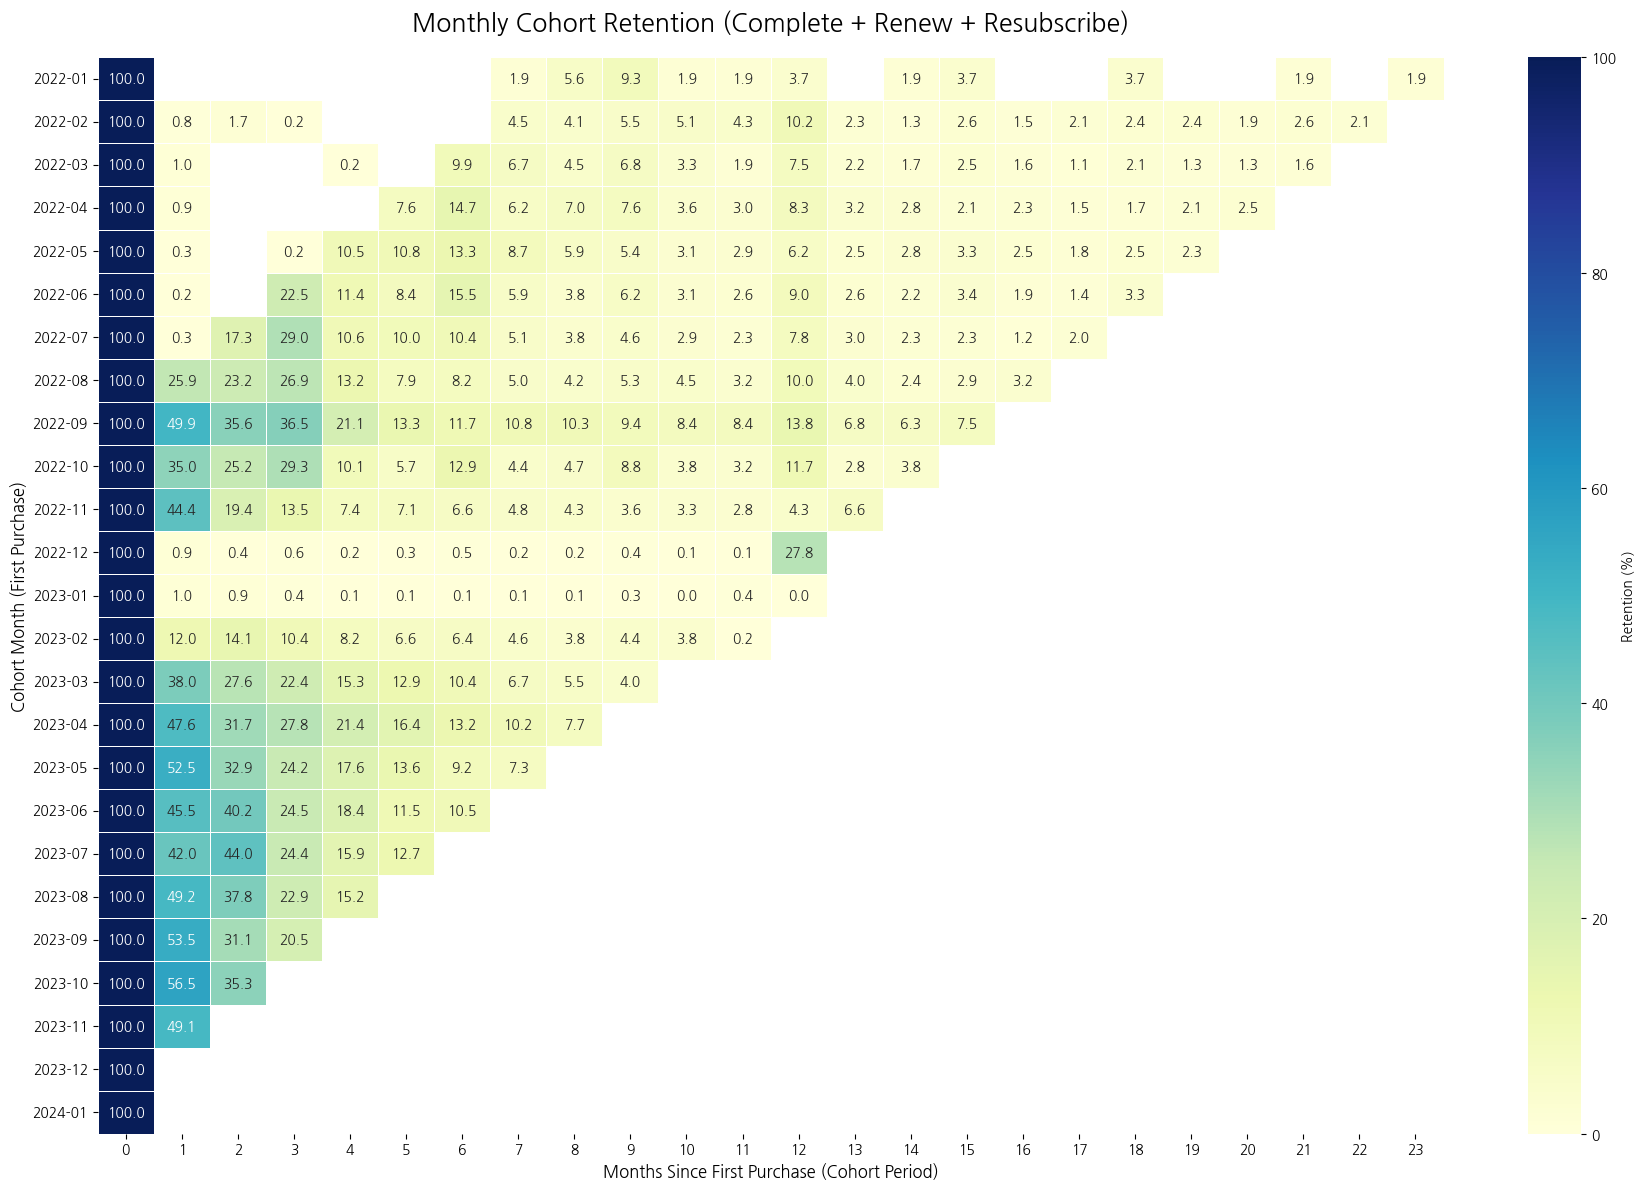

In [110]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- [1단계] 결제 마스터 타임라인 구축 (Union All) ---
# 세 테이블에서 핵심 컬럼(user_id, 시간)만 뽑아서 위아래로 합칩니다.
payment_events = pl.concat([
    complete_subscription_kr.select(["user_id", "client_event_time"]),
    renew_subscription_kr.select(["user_id", "client_event_time"]),
    resubscribe_subscription_kr.select(["user_id", "client_event_time"])
])

# --- [2단계] 코호트 기준월 및 활동월 맵핑 ---
# 유저별 최초 결제 시점(Month 0)을 구하고, 각 이벤트의 발생 시점(Order Month)을 기록합니다.
cohort_base = payment_events.with_columns([
    pl.col("client_event_time").min().over("user_id").dt.truncate("1mo").dt.to_string("%Y-%m").alias("cohort_month"),
    pl.col("client_event_time").min().over("user_id").dt.truncate("1mo").alias("cohort_month_raw"),
    pl.col("client_event_time").dt.truncate("1mo").alias("order_month")
])

# --- [3단계] 생존 기간(Period) 계산 및 중복 제거 집계 ---
cohort_data = (
    cohort_base
    .group_by(["cohort_month", "cohort_month_raw", "order_month"])
    .agg(pl.col("user_id").n_unique().alias("user_count")) # 해당 월에 결제 이력이 있는 유니크 유저 수
    .with_columns([
        ((pl.col("order_month").dt.year() - pl.col("cohort_month_raw").dt.year()) * 12 +
         (pl.col("order_month").dt.month() - pl.col("cohort_month_raw").dt.month())).alias("cohort_period")
    ])
    .filter(pl.col("cohort_period") >= 0) # 과거 이상치 데이터 방어
    .sort(["cohort_month_raw", "cohort_period"])
)

# --- [4단계] 피벗 및 리텐션 비율 계산 ---
cohort_pivot = (
    cohort_data.select(["cohort_month", "cohort_period", "user_count"])
    .to_pandas()
    .pivot(index="cohort_month", columns="cohort_period", values="user_count")
)

# Month 0 (최초 결제월)의 유저 수를 분모로 삼아 각 월의 잔존율(%) 계산
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

# --- [5단계] 시각화 (Heatmap) ---
plt.figure(figsize=(18, 12)) # 꽉 찬 데이터를 보기 위해 사이즈를 약간 키웠습니다.
sns.heatmap(
    retention, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Retention (%)'}, 
    linewidths=.5,
    vmin=0, vmax=100 # 색상 스케일을 0~100%로 고정하여 직관성 확보
)

plt.title("Monthly Cohort Retention (Complete + Renew + Resubscribe)", fontsize=18, pad=20)
plt.ylabel("Cohort Month (First Purchase)", fontsize=12)
plt.xlabel("Months Since First Purchase (Cohort Period)", fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()